In [1]:
import os
import pandas as pd
import numpy as np

from scipy.stats import rankdata

import warnings

from madrigal.utils import BASE_DIR, DATA_DIR

import seaborn as sns
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

DDI_PATH = DATA_DIR + 'drug_combination_data/DrugBank/'
VIEWS_PATH = DATA_DIR + 'drug_features/'

No CUDA runtime is found, using CUDA_HOME='$CUDA_HOME/'


['str', 'kg', 'cv']


# Utils

In [2]:
raw_drugbank_df = pd.read_pickle('../raw_drugbank_df.pkl')
print(raw_drugbank_df.columns)

drug_metadata = pd.read_pickle(os.path.join(VIEWS_PATH, "drug_metadata_ddi.pkl"))
drug_metadata["view_str"] = 1
mod_avail_df = drug_metadata[[col for col in drug_metadata.columns if col.startswith("view_")]]

drug_metadata = drug_metadata.merge(
    raw_drugbank_df[["drugbank_id", "drug_type", "description", "indication", "moa", "toxicity", "atc_codes", "targets"]].rename(columns={"indication":"indication_drugbank"}), 
    left_on='node_id', right_on='drugbank_id', how='left'
).drop(columns=[
    col for col in drug_metadata.columns 
    if col.endswith("_sig_id") or col.endswith("_pert_dose") or col.startswith("view_tx_") or col.endswith("_sig_id") or (col in {"inchi_key", "drugbank_id", "cv_dose"})
])

# use primekg to get real indications of disease
primekg = pd.read_csv(BASE_DIR + 'raw_data/PrimeKG/kg.csv')
assert primekg[["x_index", "y_index"]].drop_duplicates().shape[0] == pd.concat([
    primekg[["x_index", "y_index"]],
    primekg[["x_index", "y_index"]].rename(columns={"x_index":"y_index", "y_index":"x_index"}),
], axis=1).drop_duplicates().shape[0]  # ensure it's bidirectional

# confirm that "best" drug pairs don't have adverse ddi effects with another dataset
db_polypharmacy = pd.read_csv(DDI_PATH + 'drugbank_ddi_directed.tsv', index_col=None)[["label_indexed", "drug_index_1", "drug_index_2"]]
db_polypharmacy = pd.concat([
    db_polypharmacy,
    db_polypharmacy.rename(columns={"drug_index_1":"drug_index_2", "drug_index_2":"drug_index_1"})
], axis=0).drop_duplicates()

# FDA approved drugs from Drugbank site
approved_drugs = pd.read_csv('../approved_drug_link.csv')
organs_csv = pd.read_csv('../drugbank_ddi_organs.csv', sep='\t')
organ_class_mapping = organs_csv.set_index("ddi_class").to_dict()["organ"]  # ddi_class : organ

organ_lst = []
for organs in organ_class_mapping.values():
    organ_lst.extend(organs.split(", "))
organ_counts = Counter(organ_lst)

Index(['drugbank_id', 'drug_name', 'drug_type', 'smiles', 'inchikey',
       'description', 'indication', 'pharmacodynamics', 'moa', 'absorption',
       'metabolism', 'toxicity', 'atc_codes', 'classifications', 'targets',
       'enzymes', 'carriers', 'transporters'],
      dtype='object')


/tmp/ipykernel_1930076/1618792364.py:17: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  primekg = pd.read_csv(BASE_DIR + 'raw_data/PrimeKG/kg.csv')


In [3]:
ddi_classes = pd.read_pickle(DDI_PATH + "drugbank_ddi_directed_label_map.pkl")
all_labels = list(range(len(ddi_classes)))

to_delete = [
    10, 
    38, 
    65, 
    72,
    83,
    99, 
    147
]
to_delete_classes = [
    "adverse effects, decrease", 
    "cardiotoxicity, decrease",
    "hypertension, decrease",
    "hypoglycemia, decrease",
    "hypotension, decrease",
    "nephrotoxicity, decrease",
    "therapeutic efficacy, increase",
]
valid_ddi_class_indices = np.array([elem for elem in all_labels if elem not in to_delete])
normalized_rank_drugbank = np.load(BASE_DIR + "model_output/DrugBank/split_by_pairs/DrugBank_drugs_normalized_ranks.npy", mmap_mode="r")

In [4]:
organs_of_interest = [
    "blood", 
    "heart", 
    "kidney", 
    "gastrointestinal", 
    "liver", 
    "endocrine", 
]

custom_palette = {
    "others/general": "grey", 
    "blood": "orange",  # lightpink
    "heart": "red",  # marron
    "kidney": "purple",  # darkmagenta
    "gastrointestinal": "green",  # mediumseagreen
    "liver": "blue",  # cornflowerblue, steelblue
    "endocrine": "darkkhaki",
}

drug_ind_to_name = drug_metadata["node_name"].dropna().to_dict()
drug_name_to_ind = {name.lower():ind for ind, name in drug_ind_to_name.items()}
drug_id_to_name = drug_metadata[["node_id", "node_name"]].dropna().set_index("node_id").to_dict()["node_name"]
drug_name_to_id = {name.lower():drug_id for drug_id, name in drug_id_to_name.items()}
drug_id_to_ind = drug_metadata["node_id"].dropna().reset_index().set_index("node_id").to_dict()["index"]
primekg_indication = primekg[primekg["relation"] == "indication"]

In [5]:
def get_parpi_cancer_drug_ddi_scores(parpi_df, cancer_name, cancer_drugs):
    '''
    parpi_df: Dataframe of parpi drugs (8 in our case)
    cancer_name: name of cancer (e.g. "ovarian", "pan")
    cancer_drugs: drugs of the cancer of curiosity
    
    returns: 
    cancer_parpi_df - dataframe with the first column being pair of parpi and cancer drug, and
    following columns being ddi scores for each class
    drug_mapping: dictionary mapping cancer drug/parpi name (key) to their DB numbers (value)
    '''
    cancer_parpi_df = defaultdict(list)

    for parpi_id, parpi_name in parpi_df.itertuples(index=False):
        index_1 = drug_id_to_ind[parpi_id]
        for cancer_drug in cancer_drugs:
            if cancer_drug in parpi_df["node_id"].values:  # we are not interested in two PARPi's combinations
                print("PARPi found in pan-cancer drug")
                raise Exception
            index_2 = drug_id_to_ind[cancer_drug]
            ddi = normalized_rank_drugbank[:, index_1, index_2]
            cancer_drug_name = drug_id_to_name[cancer_drug]

            cancer_parpi_df[f"(parpi; {cancer_name} cancer drug)"].append(str(parpi_name).lower() + '; ' + str(cancer_drug_name).lower())
            cancer_parpi_df["DDI"].append(ddi)

    cancer_parpi_df = pd.DataFrame(cancer_parpi_df)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cancer_parpi_df[ddi_classes] = cancer_parpi_df["DDI"].apply(pd.Series)
    cancer_parpi_df_filtered = cancer_parpi_df.drop(columns = to_delete_classes + ["DDI"]).set_index(f"(parpi; {cancer_name} cancer drug)")
    
    return cancer_parpi_df, cancer_parpi_df_filtered

def add_organs_column(highest_long, lowest_long, organ_class_mapping, organs_of_interest, organ_counts, sample_name_col_name="(Disease 1; Disease 2; Drug 1; Drug 2)", num_least_organ=5):
    """
    Add a column indicating the DDI classes's organs to the DDI profile dataframes in place.
    Args:
        highest_long, lowest_long: Long format of DDI profiles
    """
    organs_list = []

    for _, row in highest_long.iterrows():
        ddi_class_name = str(row["ddi_class"])
        organs = list(set([organ if organ in organs_of_interest else "others/general" for organ in organ_class_mapping[ddi_class_name].split(", ")]))
        organs_list.append(organs)

    highest_long["organ"] = organs_list
    highest_long_exploded = highest_long.explode("organ").reset_index(drop=True)
    for key in organ_counts.keys():
        # check if there are any organs with < num_least_organ points
        if organ_counts[key] < num_least_organ:
            highest_long_exploded["organ"] = highest_long_exploded["organ"].replace(key, "others/general")
    
    if lowest_long is not None:
        assert (highest_long["ddi_class"] != lowest_long["ddi_class"]).sum() == 0
        lowest_long["organ"] = organs_list
        lowest_long_exploded = lowest_long.explode("organ").reset_index(drop=True)
        for key in organ_counts.keys():
            # check if there are any organs with < num_least_organ points
            if organ_counts[key] < num_least_organ:
                lowest_long_exploded["organ"] = lowest_long_exploded["organ"].replace(key, "others/general")
    else:
        lowest_long_exploded = None
            
    return highest_long_exploded, lowest_long_exploded

# Data preparation

## PARPi

In [6]:
parpi_df = pd.DataFrame.from_dict({
    "node_id": ["DB09074", "DB11760", "DB12332"],
    "node_name": ["Olaparib", "Talazoparib", "Rucaparib"]
})
parpi = parpi_df["node_id"].values
parpi_names = parpi_df["node_name"].values

for drug_name in parpi_df["node_name"]:
    drug_ind = drug_name_to_ind[drug_name.lower()]
    temp = organs_csv.iloc[db_polypharmacy[(db_polypharmacy['drug_index_1'] == drug_ind)]["label_indexed"]]
    temp["count"] = 1
    print(f"{drug_name}:", temp.shape[0])
    display(temp.groupby(by=["ddi_class", "organ"]).agg(sum).reset_index().query("count >= 5"))

Olaparib: 777


/tmp/ipykernel_1930076/3321296268.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["count"] = 1


,ddi_class,organ,count
0,"adverse effects, increase",others/general,111
1,"bleeding, increase",blood,66
3,"metabolism, decrease",liver,380
4,"metabolism, increase",liver,138
5,"methemoglobinemia, increase",blood,32
7,"neutropenia, thrombocytopenia, increase",blood,12
8,"serum level, decrease",others/general,9
9,"serum level, increase",others/general,22


/tmp/ipykernel_1930076/3321296268.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["count"] = 1


Talazoparib: 310


,ddi_class,organ,count
0,"excretion rate, decrease | serum level, increase","liver, kidney",61
3,"methemoglobinemia, increase",blood,32
4,"serum level, decrease",others/general,10
5,"serum level, increase",others/general,203


Rucaparib: 903


/tmp/ipykernel_1930076/3321296268.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp["count"] = 1


,ddi_class,organ,count
1,"excretion rate, decrease | serum level, increase","liver, kidney",102
4,"metabolism, decrease",liver,638
5,"metabolism, increase",liver,83
6,"methemoglobinemia, increase",blood,27
7,"serum level, decrease",others/general,8
8,"serum level, increase",others/general,42


## Pan-cancer drugs

In [7]:
cancer_terms_pattern = (
    r'\b(?:'
    r'cancer|oncology|'
    r'(?!tumor necrosis factor\b)tumor|'
    r'neoplasm|carcinoma|malignancy|metastasis|metastatic|'
    r'sarcoma|lymphoma|leukemia|myeloma|melanoma|cytoma|teratoma|blastoma|adenoma|glioma'
    r')\b'
)

test_data = pd.Series([
    "This text mentions tumor necrosis factor.",
    "This text mentions tumor necrosis factor and tumor.",
    "This text mentions tumor necrosis factor and cancer.",
    "Another text mentions oncology and tumor.",
    "Yet another text mentions metastatic melanoma and sarcoma.",
    "about cancer, it is known"
])

# Apply the filter using str.contains with the pattern
filtered_data = test_data[test_data.str.contains(cancer_terms_pattern, case=False, regex=True)]
print(filtered_data)

1    This text mentions tumor necrosis factor and t...
2    This text mentions tumor necrosis factor and c...
3            Another text mentions oncology and tumor.
4    Yet another text mentions metastatic melanoma ...
5                            about cancer, it is known
dtype: object


First, use curated database

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7991999/

In [8]:
all_drugbank_ids = drug_metadata['node_id'].dropna().values.tolist()
cancerdrugs_db = pd.read_table("./cancerdrugsdb.txt")
cancerdrugs_db["DrugBank ID"] = cancerdrugs_db["DrugBank ID"].str.findall(".*>(DB\d{5})<.*")
assert (cancerdrugs_db["DrugBank ID"].apply(len) > 1).sum() == 0
cancerdrugs_db = (
    cancerdrugs_db.explode("DrugBank ID").dropna(subset=["DrugBank ID"]).
    query("`DrugBank ID` in @all_drugbank_ids").
    drop(columns=["Generic", "ChEMBL", "Targets", "Last Update", "Unnamed: 14"])
)
display(cancerdrugs_db[(cancerdrugs_db["EMA"] != "Y") & (cancerdrugs_db["FDA"] != "Y") & (cancerdrugs_db["EN"] != "Y")])

all_parpi_ids = drug_metadata[drug_metadata["cv_moa"]=="PARP inhibitor"][["node_id", "node_name"]]
all_parpi_ids = pd.concat([
    all_parpi_ids, 
    drug_metadata[drug_metadata["node_name"].isin({"Pamiparib", "Fluzoparib"})][["node_name", "node_id"]]
]).reset_index(drop=True)
all_parpis_ids = all_parpi_ids["node_id"].values
pan_cancer_drugs = list(set(cancerdrugs_db["DrugBank ID"].drop_duplicates().values) - set(all_parpis_ids))
print(len(pan_cancer_drugs))

,Product,EMA,FDA,EN,Other,WHO,Year,DrugBank ID,ATC,Indications
3,Aclarubicin,N,N,N,Japan,N,NaN,DB11617,L01DB04,NaN
15,Amrubicin,N,N,N,Japan,N,2002.0,DB06263,L01DB10,NaN
16,Amsacrine,N,N,N,NaN,N,1987.0,DB00276,L01XX01,"Leukemia, Acute; Refractory Leukemia"
31,Belotecan,N,N,N,South Korea,N,2003.0,DB12459,L01CE04,NaN
55,Carmofur,N,N,N,Japan,N,NaN,DB09010,L01BC04,NaN
220,Pirarubicin,N,N,N,Japan,N,NaN,DB11616,L01DB08,NaN
238,Ranimustine,N,N,N,Japan,N,NaN,DB13832,L01AD07,NaN
271,"Tegafur, Uracil",N,N,N,Japan,N,NaN,DB09256,L01BC03; L01BC53,Advanced Gastric Cancer


215


Then, supplement with DrugCentral (thru PrimeKG)

In [9]:
pan_cancer_indications = primekg_indication[
    primekg_indication["x_name"].str.contains(cancer_terms_pattern, case=False) & \
    (primekg_indication["x_type"] == "disease") & \
    (primekg_indication["y_type"] == "drug")
]
print(pan_cancer_indications["x_name"].unique())

# remove any drugs that don't appear in metadata OR any drugs that are not fda approved
print(set(pan_cancer_indications["y_id"].unique()) & set(drug_metadata["node_id"].dropna().values) - set(approved_drugs["DrugBank ID"].values) - set(pan_cancer_drugs))
pan_cancer_drugs += list(
    (
        set(pan_cancer_indications["y_id"].unique()) & set(drug_metadata["node_id"].dropna().values) & \
        set(approved_drugs["DrugBank ID"].values)
    ) - set(parpi_df["node_id"].values) - set(pan_cancer_drugs) - set(all_parpis_ids)
)
print(len(pan_cancer_drugs))

['superficial multifocal basal cell carcinoma'
 'humoral hypercalcemia of malignancy'
 'acute lymphoblastic leukemia (disease)'
 'leukemia, lymphocytic, susceptibility to'
 'acute lymphoblastic/lymphocytic leukemia'
 'precursor T-cell acute lymphoblastic leukemia'
 'primary cutaneous T-cell lymphoma' 'Hodgkins lymphoma'
 'classic Hodgkin lymphoma'
 'classic Hodgkin lymphoma, lymphocyte-rich type' 'non-Hodgkin lymphoma'
 'lymphoma' 'mantle cell lymphoma' 'lymphoma, non-Hodgkin, familial'
 'B-cell neoplasm' 'hairy cell leukemia' 'hairy cell leukemia variant'
 'melanoma' 'follicular lymphoma' 'neoplasm of mature B-cells'
 "Kaposi's sarcoma (disease)" 'female breast carcinoma' 'ovarian cancer'
 'hereditary breast ovarian cancer syndrome'
 'ovarian small cell carcinoma' 'yolk sac tumor'
 'borderline epithelial tumor of ovary'
 'malignant non-dysgerminomatous germ cell tumor of ovary'
 'familial ovarian cancer'
 'hereditary site-specific ovarian cancer syndrome'
 'malignant germ cell tumor o

In [10]:
primekg_drugs_not_approved_interesting = ["DB06266", "DB12323", "DB11812", "DB06185", "DB04942", "DB11737", "DB13164"]
pan_cancer_drugs += primekg_drugs_not_approved_interesting

Finally, supplement with ATC==L01

In [11]:
drugs_atc_l01 = drug_metadata[
    (~drug_metadata["atc_codes"].isna()) & \
    (drug_metadata["atc_codes"].apply(
        lambda lst: sum([atc.startswith("L01") for atc in lst] if lst == lst else [0])) > 0
    ) & \
    (~drug_metadata["node_id"].isna()) & \
    (~drug_metadata["node_id"].isin(all_parpis_ids))
][["node_id", "node_name"]]
len(drugs_atc_l01)

202

In [12]:
print(set(drugs_atc_l01["node_id"].values) - set(pan_cancer_drugs))

{'DB13334', 'DB13339', 'DB11841', 'DB11697', 'DB13069', 'DB11618', 'DB13304', 'DB00648', 'DB11689', 'DB06233', 'DB11678', 'DB13318', 'DB00482', 'DB04977', 'DB00992', 'DB11999', 'DB11717', 'DB08486', 'DB13243', 'DB05168', 'DB13677', 'DB04996', 'DB00179', 'DB04849', 'DB12967', 'DB00261', 'DB12832', 'DB11907', 'DB13543', 'DB11526'}


Remove:
- DB04996: Satraplatin, discontinued
- DB11907: Rociletinib, discontinued
- DB13318: Demecolcine, no info
- DB14769: Pamiparib, PARPi
- DB06233: Ridaforolimus, discontinued
- DB13334: Mannosulfan, no info
- DB11618: Zorubicin, no info
- DB00261: Anagrelide, treat thrombocythemia secondary to malignancies
- DB00179: Masoprocol, actinic keratoses
- DB13243: Tiazofurine, discontinued
- DB13304: Triaziquone, no info
- DB00992: Methyl aminolevulinate, actinic keratosis
- DB08486: Efaproxiral, discontinued
- DB11526: Mastinib, vet drug
- DB12967: Mitoguazone, discontinued
- DB13543: Mitobronitol, no info
- DB13339: Etoglucid, no info

In [13]:
drugs_atc_l020304 = drug_metadata[
    (~drug_metadata["atc_codes"].isna()) & \
    (drug_metadata["atc_codes"].apply(
        lambda lst: sum([atc.startswith("L02") or atc.startswith("L03") or atc.startswith("L04") for atc in lst] if lst == lst else [0])) > 0  # must be L
    ) & \
    (
        (drug_metadata["description"].str.contains(cancer_terms_pattern, case=False)) | \
        (drug_metadata["disease.area"].str.contains(cancer_terms_pattern, case=False)) | \
        (drug_metadata["indication"].str.contains(cancer_terms_pattern, case=False)) | \
        (drug_metadata["indication_drugbank"].str.contains(cancer_terms_pattern, case=False)) | \
        (drug_metadata["moa"].str.contains(cancer_terms_pattern, case=False))  # one field must contain cancer-related mentioning
    ) & \
    (~drug_metadata["node_id"].isna()) & \
    (~drug_metadata["node_id"].isin(all_parpis_ids))
][["node_id", "node_name"]]

In [14]:
print(set(drugs_atc_l020304["node_id"].values) - set(pan_cancer_drugs))

{'DB00106', 'DB01097', 'DB12154', 'DB11996', 'DB00357', 'DB11366'}


Remove: 
- DB00106: Abarelix, withdrawn
- DB01097: Leflunomide, unrelated
- DB11366: Roquinimex, discontinued
- DB11996: Thymopentin, unclear status

In [15]:
atc_l_drugs_interesting = [
    "DB12154", "DB00357", 
    "DB04977", "DB12832", "DB11841", "DB11717", "DB11678", "DB11697", "DB13069",
    "DB00648", "DB11689", "DB05168", "DB00482", "DB04849", "DB11999", "DB13677", 
]
pan_cancer_drugs += atc_l_drugs_interesting
pan_cancer_drugs += [drug_name_to_id["ceralasertib"]]  # add investigatory drugs that would be used in analyses, mk-1775
pan_cancer_drugs = list(set(pan_cancer_drugs) - set(all_parpis_ids))
print(len(pan_cancer_drugs))

287


In [16]:
all_other_drugs_list = list(
    set(drug_metadata['node_id'].dropna().values) & set(approved_drugs["DrugBank ID"].values) - \
    set(all_parpis_ids) - set(pan_cancer_drugs)
)  # remove parpis and ensure the drug has been approved
print(len(all_other_drugs_list))

2340


In [17]:
pan_cancer_parpi_df, pan_cancer_parpi_df_filtered = get_parpi_cancer_drug_ddi_scores(parpi_df, "pan", pan_cancer_drugs)

all_pan_cancer_long = pd.melt(
    pan_cancer_parpi_df_filtered.reset_index(), 
    id_vars=pan_cancer_parpi_df_filtered.index.name, 
    value_vars=pan_cancer_parpi_df_filtered.columns, 
    var_name="ddi_class"
)

test_long = all_pan_cancer_long.copy()
test_long[["parpi", "cancer drug"]] = test_long["(parpi; pan cancer drug)"].str.split("; ", expand=True)
test_long["cancer drug id"] = test_long["cancer drug"].apply(lambda x: drug_name_to_id[x])
test_long = test_long.drop(columns=["(parpi; pan cancer drug)"])[["parpi", "cancer drug", "cancer drug id", "ddi_class", "value"]]

all_pan_cancer_long_exploded, _ = add_organs_column(
    all_pan_cancer_long, None, 
    organ_class_mapping, organs_of_interest, organ_counts, 
    sample_name_col_name="(parpi; pan cancer drug)", num_least_organ=5
)

# list of organs that can be indexed into, corresponding to the 140 ddi classes (filtered)
organ_list = all_pan_cancer_long[all_pan_cancer_long["(parpi; pan cancer drug)"] == "olaparib; paclitaxel"]["organ"].values

# maps each of the 140 (adverse) ddi classes of interest to a SPECIFIC organ
specific_organs_mapping = defaultdict(list)
for i, organs in enumerate(organ_list):
    for organ in organs:
        specific_organs_mapping[organ].append(i)

# PARPi Analyses

## Clinically investigated PARP-inhibitor pairs

In [19]:
drug_1_name = "olaparib"
drug_2_name = "paclitaxel"
drug_1_ind = drug_name_to_ind[drug_1_name]
drug_2_ind = drug_name_to_ind[drug_2_name]
ddi_adverse_labels = db_polypharmacy[(db_polypharmacy['drug_index_1'] == drug_1_ind) & (db_polypharmacy['drug_index_2'] == drug_2_ind)]['label_indexed'].values
if ddi_adverse_labels.shape[0] != 0:
    print(f"{drug_1_name}, {drug_2_name}:", ddi_classes[ddi_adverse_labels].values[0])
else:
    print(f"{drug_1_name}, {drug_2_name}:", "No ground truth.")

olaparib, paclitaxel: metabolism, increase


In [26]:
drug_1_name = "olaparib"
drug_2_name = "abiraterone"
drug_1_ind = drug_name_to_ind[drug_1_name]
drug_2_ind = drug_name_to_ind[drug_2_name]
ddi_adverse_labels = db_polypharmacy[(db_polypharmacy['drug_index_1'] == drug_1_ind) & (db_polypharmacy['drug_index_2'] == drug_2_ind)]['label_indexed'].values
if ddi_adverse_labels.shape[0] != 0:
    print(f"{drug_1_name}, {drug_2_name}:", ddi_classes[ddi_adverse_labels].values[0])
else:
    print(f"{drug_1_name}, {drug_2_name}:", "No ground truth.")

olaparib, abiraterone: No ground truth.


In [27]:
drug_1_name = "olaparib"
drug_2_name = "ceralasertib"
drug_1_ind = drug_name_to_ind[drug_1_name]
drug_2_ind = drug_name_to_ind[drug_2_name]
ddi_adverse_labels = db_polypharmacy[(db_polypharmacy['drug_index_1'] == drug_1_ind) & (db_polypharmacy['drug_index_2'] == drug_2_ind)]['label_indexed'].values
if ddi_adverse_labels.shape[0] != 0:
    print(f"{drug_1_name}, {drug_2_name}:", ddi_classes[ddi_adverse_labels].values[0])
else:
    print(f"{drug_1_name}, {drug_2_name}:", "No ground truth.")

olaparib, ceralasertib: No ground truth.


Neutropenia-related outcomes: olaparib pairs n=287 | Olaparib + Paclitaxel 95.99% | Olaparib + Abiraterone 28.40% | Olaparib + Ceralasertib 70.21%
Hematological outcomes: olaparib pairs n=287 | Olaparib + Paclitaxel 96.69% | Olaparib + Abiraterone 37.46% | Olaparib + Ceralasertib 87.98%


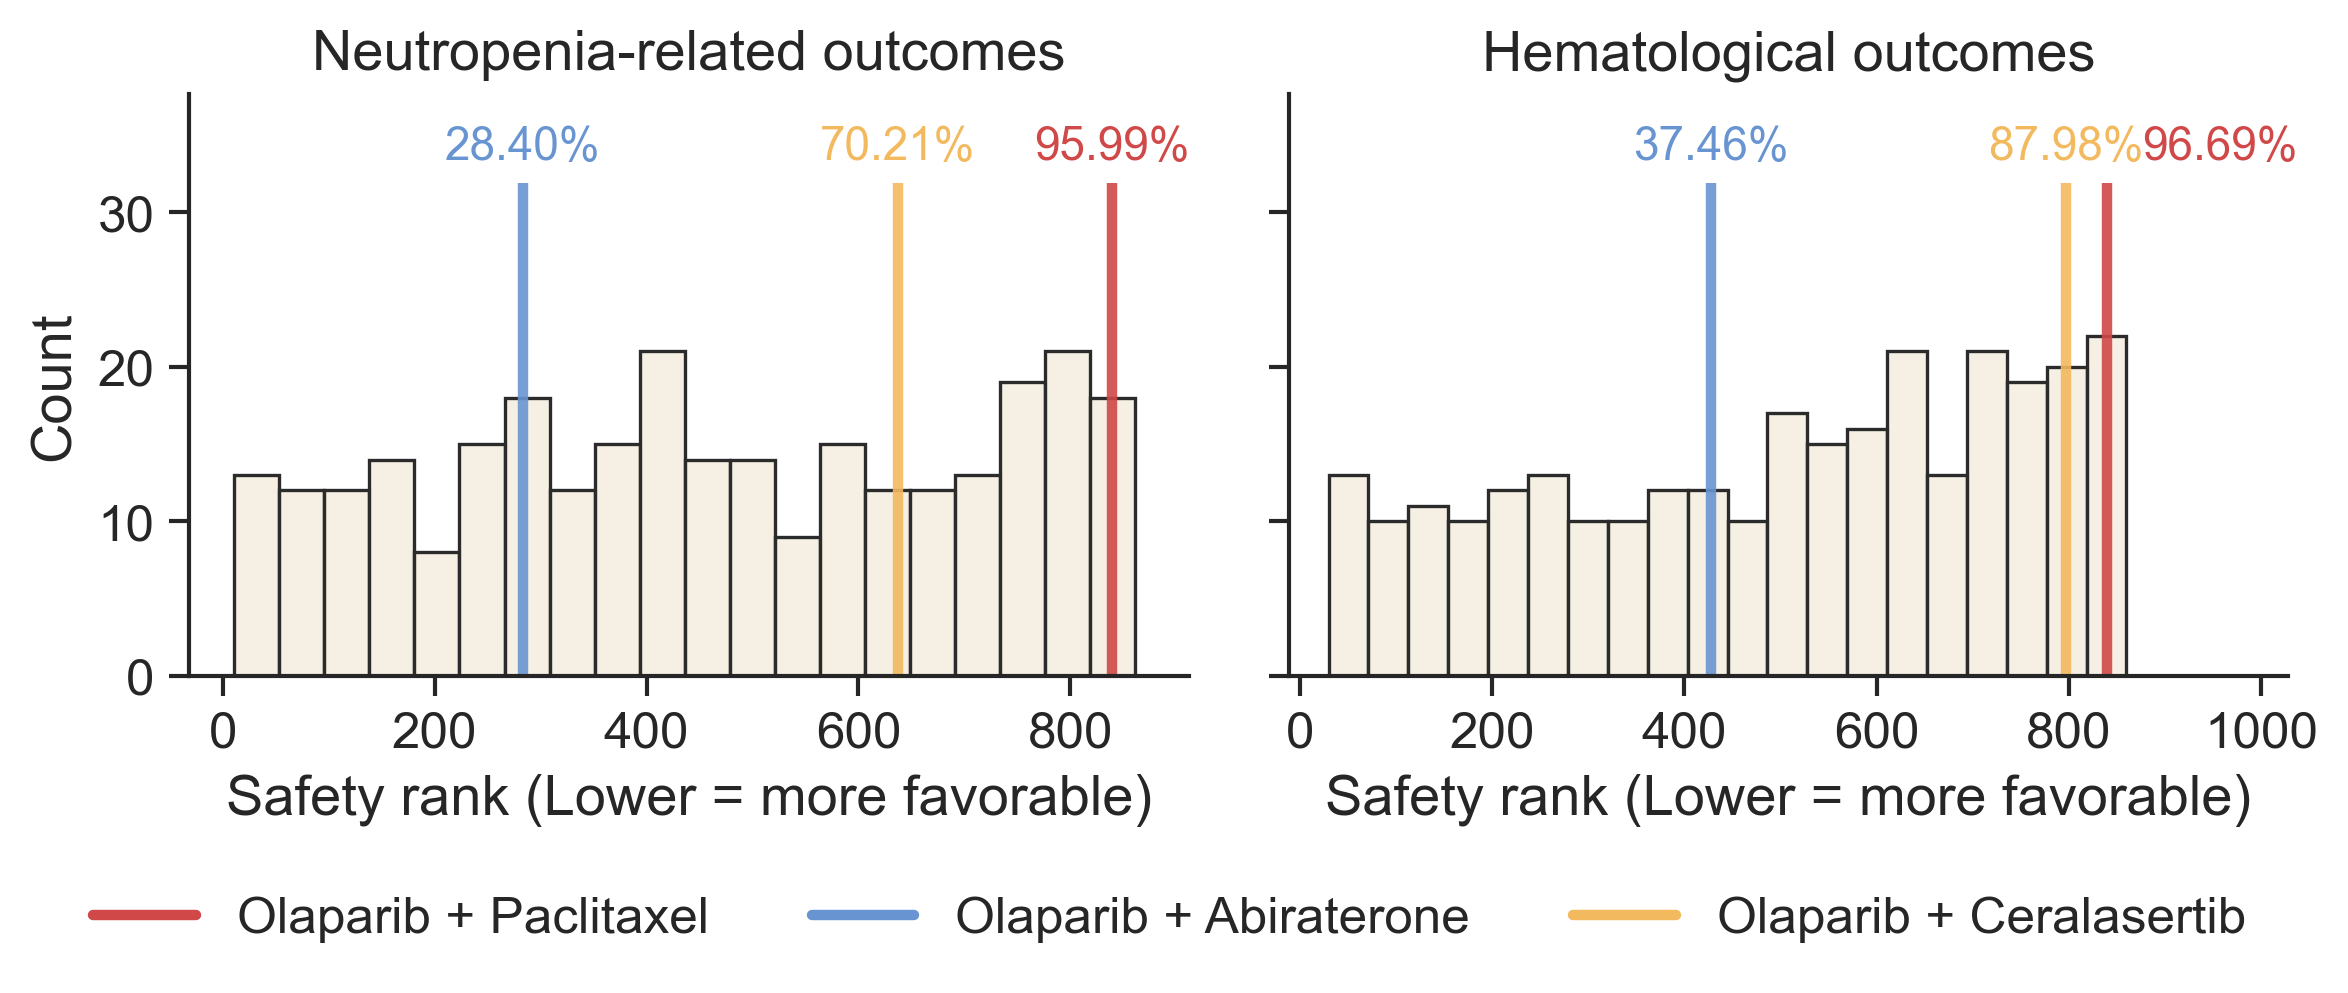

In [18]:
from matplotlib import font_manager as fm
from matplotlib.lines import Line2D

arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass

# ---- outcome column groups -------------------------------------------------
neutropenia_cols = [
    col for col in pan_cancer_parpi_df_filtered.columns if col in {
        "cytopenia, increase",
        "myelosuppression, anemia, severe leukopenia, increase",
        "neutropenia, increase",
        "neutropenia, thrombocytopenia, increase",
    }
]
hematological_cols = [
    col for col in pan_cancer_parpi_df_filtered.columns
    if "blood" in organ_class_mapping[col]
]

def highest_5_mean(df):
    """Row-wise mean of the 5 highest values."""
    return df.apply(
        lambda row: np.mean(np.partition(row.values, len(row) - 5)[-5:]), axis=1
    )

# ---- studied olaparib combinations to highlight ----------------------------
combo_styles = {
    "olaparib; paclitaxel":   ("#D04848", "Olaparib + Paclitaxel"),
    "olaparib; abiraterone":  ("#6895D2", "Olaparib + Abiraterone"),
    "olaparib; ceralasertib": ("#F3B95F", "Olaparib + Ceralasertib"),
}

def compute_olaparib_ranks(parpi_cancer_drug_scores):
    """Rank all PARPi-cancer drug pairs by safety score, then return the
    olaparib subset along with the rank/percentile of each highlighted combo."""
    pairs = parpi_cancer_drug_scores.index.values
    ranks = rankdata(parpi_cancer_drug_scores.values, method="average")
    olaparib_ranks = np.array(
        [r for p, r in zip(pairs, ranks) if p.split("; ")[0] == "olaparib"]
    )
    combo_ranks, combo_pct = {}, {}
    for combo in combo_styles:
        rank = [r for p, r in zip(pairs, ranks) if p == combo][0]
        pct = (
            (olaparib_ranks < rank).mean() + (olaparib_ranks <= rank).mean()
        ) / 2 * 100
        combo_ranks[combo], combo_pct[combo] = rank, pct
    return olaparib_ranks, combo_ranks, combo_pct

def _spread_labels(ax, texts, renderer):
    """Nudge percentage labels rightward so they never overlap, then widen the
    x-limits if a label ends up poking past the axis edge."""
    inv = ax.transData.inverted()
    items = []
    for t in texts:
        bb = t.get_window_extent(renderer=renderer)
        x0 = inv.transform((bb.x0, 0))[0]
        x1 = inv.transform((bb.x1, 0))[0]
        items.append([t, x0, x1])
    items.sort(key=lambda it: it[1])
    pad = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.02
    for i in range(1, len(items)):
        overlap = items[i - 1][2] + pad - items[i][1]
        if overlap > 0:
            t, _, _ = items[i]
            px, py = t.get_position()
            t.set_position((px + overlap, py))
            items[i][1] += overlap
            items[i][2] += overlap
    lo, hi = ax.get_xlim()
    ax.set_xlim(min(lo, items[0][1]), max(hi, items[-1][2]))

def plot_safety_histograms(panels, figsize, outpath=None, title_weight="normal",
                           title_fontsize=None, bins=20):
    """Plot one safety-rank histogram per panel with a shared vertical scale
    and a single bottom legend.

    panels: list of (scores Series, panel title).
    """
    sns.set(style="ticks", context="paper", font_scale=1.4)
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["Arial"]

    fig, axes = plt.subplots(1, len(panels), figsize=figsize, dpi=300, sharey=True)
    axes = np.atleast_1d(axes)

    computed = []
    for ax, (scores, title) in zip(axes, panels):
        olaparib_ranks, combo_ranks, combo_pct = compute_olaparib_ranks(scores)
        sns.histplot(
            x=olaparib_ranks, bins=bins, stat="count",
            color="#F3ECDB", edgecolor="#2B2B2B", lw=0.8, ax=ax,
        )
        print(
            f"{title}: olaparib pairs n={len(olaparib_ranks)} | "
            + " | ".join(
                f"{combo_styles[c][1]} {combo_pct[c]:.2f}%" for c in combo_styles
            )
        )
        computed.append((ax, title, combo_ranks, combo_pct))

    # shared vertical scale, with headroom above the bars for the vlines/labels
    max_count = max(p.get_height() for ax, *_ in computed for p in ax.patches)
    vline_top = max_count * 1.45

    panel_texts = []
    for ax, title, combo_ranks, combo_pct in computed:
        texts = []
        for combo, (color, _) in combo_styles.items():
            ax.vlines(combo_ranks[combo], 0, vline_top, color=color, alpha=0.9, lw=2.5)
            texts.append(ax.text(
                combo_ranks[combo], vline_top * 1.03, f"{combo_pct[combo]:.2f}%",
                fontsize=11, color=color, ha="center", va="bottom",
            ))
        ax.set_ylim(0, vline_top * 1.18)
        ax.set_xlabel("Safety rank (Lower = more favorable)")
        ax.set_title(title, fontweight=title_weight, fontsize=title_fontsize)
        sns.despine(ax=ax)
        panel_texts.append((ax, texts))

    axes[0].set_ylabel("Count")
    for ax in axes[1:]:
        ax.set_ylabel("")

    handles = [
        Line2D([0], [0], color=c, lw=2.5, label=l) for c, l in combo_styles.values()
    ]
    fig.tight_layout(rect=[0, 0.1, 1, 1])
    fig.legend(
        handles=handles, loc="lower center", ncol=3, frameon=False,
        bbox_to_anchor=(0.5, 0.0),
    )

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, texts in panel_texts:
        _spread_labels(ax, texts, renderer)

    if outpath is not None:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, format="svg", dpi=300, bbox_inches="tight")
    plt.show()

# ---- median aggregation: neutropenia-related & hematological outcomes ------
plot_safety_histograms(
    panels=[
        (pan_cancer_parpi_df_filtered[neutropenia_cols].median(axis=1),
         "Neutropenia-related outcomes"),
        (pan_cancer_parpi_df_filtered[hematological_cols].median(axis=1),
         "Hematological outcomes"),
    ],
    figsize=(8, 3.4),
    title_weight="bold",
    outpath="./fig4_known_olaparib_combos_histogram_neutropenia_median_bottleneck.svg",
)

Mean of neutropenia-related outcomes: olaparib pairs n=287 | Olaparib + Paclitaxel 95.64% | Olaparib + Abiraterone 31.53% | Olaparib + Ceralasertib 71.25%
Mean of hematological-related outcomes: olaparib pairs n=287 | Olaparib + Paclitaxel 96.69% | Olaparib + Abiraterone 34.32% | Olaparib + Ceralasertib 77.18%
Highest 5 mean of hematological-related outcomes: olaparib pairs n=287 | Olaparib + Paclitaxel 96.34% | Olaparib + Abiraterone 35.02% | Olaparib + Ceralasertib 84.15%


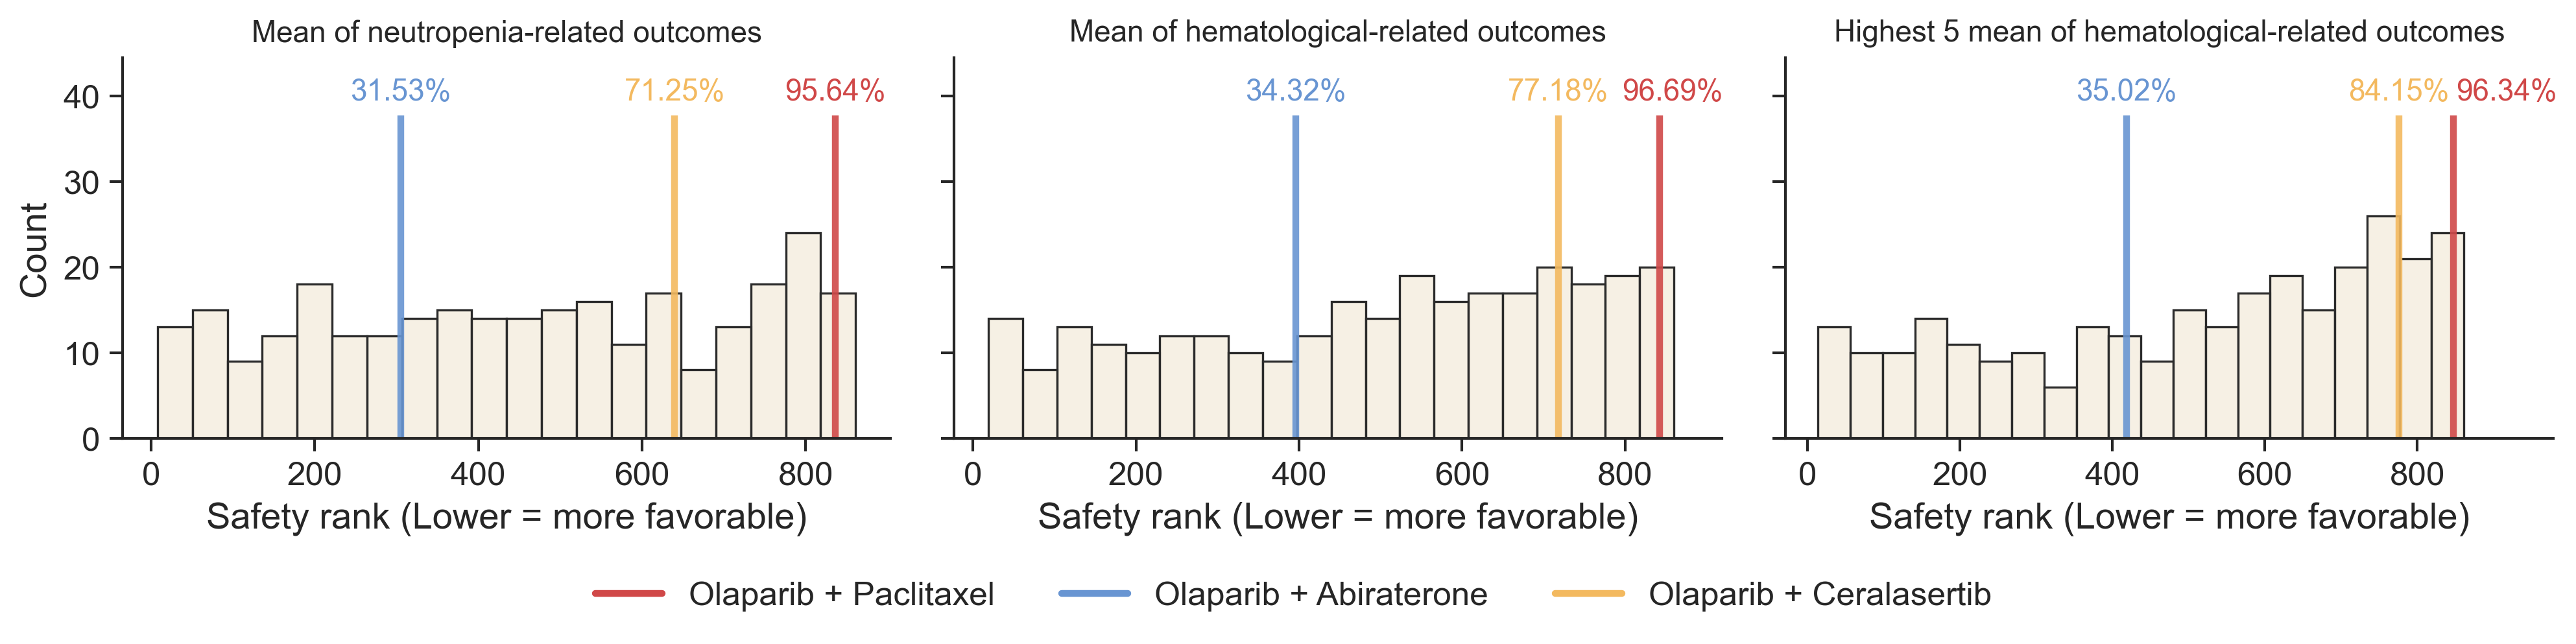

In [19]:
# ---- mean & highest-5-mean aggregations ------------------------------------
# Uses the helpers defined in the cell above (plot_safety_histograms, etc.).
plot_safety_histograms(
    panels=[
        (pan_cancer_parpi_df_filtered[neutropenia_cols].mean(axis=1),
         "Mean of neutropenia-related outcomes"),
        (pan_cancer_parpi_df_filtered[hematological_cols].mean(axis=1),
         "Mean of hematological-related outcomes"),
        (highest_5_mean(pan_cancer_parpi_df_filtered[hematological_cols]),
         "Highest 5 mean of hematological-related outcomes"),
    ],
    figsize=(13.5, 3.4),
    title_weight="normal",
    title_fontsize=11,
    outpath="./fig4_known_olaparib_combos_histogram_mean_highest5_bottleneck.svg",
)

## Comparing different groups of drug combinations

In [18]:
groups_organ_results = dict() # medians to display for each bar

### Clinically-investigating PARPi-cancer drug combinations

In [19]:
studied_parpi_combos = {
    'olaparib':['bevacizumab', 'temozolomide', 'cediranib', 'ramucirumab', 'alpelisib', 'capivasertib', 'selumetinib', 'durvalumab', 'ceralasertib', 'prexasertib', 'mk-1775', 'abiraterone'], 
    'veliparib':['paclitaxel', 'carboplatin', 'cisplatin', 'gemcitabine', 'temozolomide', 'irinotecan', 'fluorouracil', 'lapatinib'],
    'rucaparib':['temozolomide', 'sacituzumab'],
    'talazoparib':['ZEN-3694', "enzalutamide"],
    'niraparib':['bevacizumab', 'pembrolizumab', 'ipilimumab', 'nivolumab', 'dostarlimab', 'abiraterone']
}

parpi_drug_pairs_phase = {
    "olaparib; temozolomide": "phase 2",
    "olaparib; cediranib": "phase 3",
    "olaparib; alpelisib": "phase 1",
    "olaparib; capivasertib": "phase 1",
    "olaparib; selumetinib": "phase 1",
    "olaparib; ceralasertib": "phase 2",
    "olaparib; prexasertib": "phase 1",
    "olaparib; mk-1775": "phase 2", 
    "olaparib; abiraterone": "approved",
    "olaparib; paclitaxel": "control",
    
    "veliparib; paclitaxel": "phase 2",
    "veliparib; carboplatin": "phase 3",
    "veliparib; cisplatin": "phase 2",
    "veliparib; gemcitabine": "phase 2",
    "veliparib; temozolomide": "phase 2",
    "veliparib; irinotecan": "phase 2",
    "veliparib; fluorouracil": "phase 2",
    "veliparib; lapatinib": "phase 1",
    "rucaparib; temozolomide": "phase 2",
    
    "talazoparib; enzalutamide": "approved",
    
    "niraparib; abiraterone": "approved",
}

In [20]:
groups_organ_results["PARPi combinations (clinically investigated or approved)"] = dict()

for parpi_name, cancer_drug_list in studied_parpi_combos.items():
    if parpi_name not in parpi_df["node_name"].str.lower().values:
        continue
    for cancer_drug_name in cancer_drug_list:
        if cancer_drug_name in drug_metadata["node_name"].dropna().str.lower().values:
            print(parpi_name, cancer_drug_name)
            parpi_index = drug_name_to_ind[parpi_name]
            cancer_drug_index = drug_name_to_ind[cancer_drug_name]
            ddi_filtered = normalized_rank_drugbank[:, parpi_index, cancer_drug_index][valid_ddi_class_indices]

            # specific_organs_mapping
            groups_organ_results["PARPi combinations (clinically investigated or approved)"][f"{parpi_name}; {cancer_drug_name}"] = dict()
            for organ, organ_ddi_index_lst in specific_organs_mapping.items():
                groups_organ_results["PARPi combinations (clinically investigated or approved)"][f"{parpi_name}; {cancer_drug_name}"][organ] = ddi_filtered[organ_ddi_index_lst]

olaparib temozolomide
olaparib cediranib
olaparib alpelisib
olaparib capivasertib
olaparib selumetinib
olaparib ceralasertib
olaparib prexasertib
olaparib mk-1775
olaparib abiraterone
rucaparib temozolomide
talazoparib enzalutamide


### PARPi + cancer drugs

In [21]:
groups_organ_results["PARPi combinations (with any other cancer drug)"] = dict()
for parpi_name in parpi_df["node_name"].values:
    for cancer_drug_id in pan_cancer_drugs:
        cancer_drug_name = drug_id_to_name[cancer_drug_id].lower()
        if cancer_drug_name in drug_metadata["node_name"].dropna().str.lower().values:
            parpi_index = drug_name_to_ind[parpi_name.lower()]
            cancer_drug_index = drug_name_to_ind[cancer_drug_name]
            ddi_filtered = normalized_rank_drugbank[:, parpi_index, cancer_drug_index][valid_ddi_class_indices]

            # specific_organs_mapping
            groups_organ_results["PARPi combinations (with any other cancer drug)"][f"{parpi_name}; {cancer_drug_name}"] = dict()
            for organ, organ_ddi_index_lst in specific_organs_mapping.items():
                groups_organ_results["PARPi combinations (with any other cancer drug)"][f"{parpi_name}; {cancer_drug_name}"][organ] = ddi_filtered[organ_ddi_index_lst]

### Approved drug combinations

In [22]:
all_dbids = set(drug_metadata["node_id"].dropna().values)
all_clinical_combos = pd.read_csv(BASE_DIR + "raw_data/cdcdb/all_combs_unormalized.csv")[["drugbank_identifiers", "source_id", "source"]].dropna(subset=["drugbank_identifiers"])
all_clinical_combos["drugbank_identifiers"] = all_clinical_combos["drugbank_identifiers"].apply(
    lambda lst: ";".join(sorted([
        dbid for dbid in lst.strip("[]\"").split("\", \"") 
        if dbid.startswith("DB") and len(dbid) == 7 and dbid in all_dbids
    ]))
)
all_clinical_combos = all_clinical_combos[all_clinical_combos["drugbank_identifiers"].apply(len) >= 15].drop_duplicates().reset_index(drop=True)  # 15 == 2 drugs
all_clinical_combos["label"] = np.arange(all_clinical_combos.shape[0])
display(all_clinical_combos)
print(all_clinical_combos.drop_duplicates(subset=["drugbank_identifiers"]).shape[0])

,drugbank_identifiers,source_id,source,label
0,DB00529;DB01004,NCT00000134,clinicaltrials.gov,0
1,DB00529;DB01004,NCT00000136,clinicaltrials.gov,1
2,DB00260;DB00363,NCT00000372,clinicaltrials.gov,2
3,DB00704;DB01104,NCT00000451,clinicaltrials.gov,3
4,DB00007;DB00396;DB00783,NCT00001322,clinicaltrials.gov,4
...,...,...,...,...
16894,DB00977;DB09389,NaN,orangebook,16894
16895,DB00823;DB00977,NaN,orangebook,16895
16896,DB00304;DB00977,NaN,orangebook,16896
16897,DB00957;DB00977,NaN,orangebook,16897


8728


#### Orange book combos (incl. all)

In [23]:
temp = all_clinical_combos[all_clinical_combos["source"].apply(lambda st: "orangebook" in st)].copy()[["drugbank_identifiers", "label"]]
temp["drugbank_identifiers"] = temp["drugbank_identifiers"].apply(lambda lst: ";".join(lst.split(";")))
temp = temp[temp["drugbank_identifiers"].apply(len) >= 15]
temp["drugbank_identifiers"] = temp["drugbank_identifiers"].str.split(";")
temp = temp.explode("drugbank_identifiers")
temp["value"] = 1
temp = pd.pivot_table(temp, values="value", index="drugbank_identifiers", columns="label").fillna(0).rename_axis(index=None)
temp = pd.DataFrame(temp.values @ temp.values.T > 0, dtype=bool, columns=temp.index, index=temp.index)
temp = pd.melt(temp.reset_index(), id_vars="index")
temp = temp[temp["value"] & (temp["index"] != temp["variable"])].drop(columns=["value"]).rename(columns={"index":"drug_1", "variable":"drug_2"}).reset_index(drop=True)
orange_book_combos_pairs_list = temp.values.tolist()

In [24]:
from time import time
groups_organ_results["FDA-approved drug combinations"] = dict()

start = time()
for i, (drug_1_id, drug_2_id) in enumerate(orange_book_combos_pairs_list):
    drug_1_name = drug_id_to_name[drug_1_id].lower()
    drug_2_name = drug_id_to_name[drug_2_id].lower()
    drug_1_index = drug_name_to_ind[drug_1_name]
    drug_2_index = drug_name_to_ind[drug_2_name]
    ddi_filtered = normalized_rank_drugbank[:, drug_1_index, drug_2_index][valid_ddi_class_indices]
    
    # specific_organs_mapping
    groups_organ_results["FDA-approved drug combinations"][f"{drug_1_name}; {drug_2_name}"] = dict()
    for organ, organ_ddi_index_lst in specific_organs_mapping.items():
        groups_organ_results["FDA-approved drug combinations"][f"{drug_1_name}; {drug_2_name}"][organ] = ddi_filtered[organ_ddi_index_lst]
        
    if i % 1000 == 1:
        print(i)
        
end = time()
print((end-start)/60)

1
1001
13.036201870441436


#### Orange book (at least one cancer drug)

In [25]:
orange_book_combos_pan_cancer_pairs_list = [pair for pair in orange_book_combos_pairs_list 
                                            if pair[0] in pan_cancer_drugs + all_parpis_ids.tolist() or pair[1] in pan_cancer_drugs + all_parpis_ids.tolist()]
len(orange_book_combos_pan_cancer_pairs_list)

82

In [26]:
groups_organ_results["FDA-approved drug combinations (at least one cancer drug)"] = dict()

for i, (drug_1_id, drug_2_id) in enumerate(orange_book_combos_pan_cancer_pairs_list):
    drug_1_name = drug_id_to_name[drug_1_id].lower()
    drug_2_name = drug_id_to_name[drug_2_id].lower()
    drug_1_index = drug_name_to_ind[drug_1_name]
    drug_2_index = drug_name_to_ind[drug_2_name]
    ddi_filtered = normalized_rank_drugbank[:, drug_1_index, drug_2_index][valid_ddi_class_indices]
    
    # specific_organs_mapping
    groups_organ_results["FDA-approved drug combinations (at least one cancer drug)"][f"{drug_1_name}; {drug_2_name}"] = dict()
    for organ, organ_ddi_index_lst in specific_organs_mapping.items():
        groups_organ_results["FDA-approved drug combinations (at least one cancer drug)"][f"{drug_1_name}; {drug_2_name}"][organ] = ddi_filtered[organ_ddi_index_lst]
    
    if i % 1000 == 1:
        print(i)

1


### Clinical trials

In [27]:
clinical_trial_combos = pd.read_csv(BASE_DIR + "raw_data/cdcdb/aact_combs__with_identifiers.csv", index_col=0)
ct_combos_df = clinical_trial_combos[["nct_id", "design_group_id", "identifiers_entity", "why_stopped", "phase", "overall_status", "downcase_mesh_terms"]]
ct_combos_df["downcase_mesh_terms"] = ct_combos_df["downcase_mesh_terms"].apply(lambda x: x.strip("[']").split("', '") if x == x else [])
ct_combos_df = ct_combos_df.groupby(by=["design_group_id", "nct_id"]).agg(list)
ct_combos_df["identifiers_entity"] = ct_combos_df["identifiers_entity"].apply(
    lambda lst: ";".join(sorted([
        tup_str.split("', '")[0].strip("('") for tup_str in lst if tup_str.split("', '")[0].strip("('").startswith("DB") and len(tup_str.split("', '")[0].strip("('")) == 7 and tup_str.split("', '")[0].strip("('") in all_dbids
    ]))
)
ct_combos_df["downcase_mesh_terms"] = ct_combos_df["downcase_mesh_terms"].apply(
    lambda lst: sum(lst, start=[])
)
for col in ["why_stopped", "phase", "overall_status"]:
    ct_combos_df[col] = ct_combos_df[col].apply(lambda lst: lst[0] if isinstance(lst, list) and len(lst) > 0 else "")
ct_combos_df = ct_combos_df[ct_combos_df["identifiers_entity"].apply(len) >= 15].reset_index().drop_duplicates(subset=["nct_id", "identifiers_entity"]).rename(columns={"identifiers_entity": "drugbank_ids"})
ct_combos_df.sort_values("nct_id").reset_index(drop=True)

/tmp/ipykernel_1930076/3274886028.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_trial_combos = pd.read_csv(BASE_DIR + "raw_data/cdcdb/aact_combs__with_identifiers.csv", index_col=0)
/tmp/ipykernel_1930076/3274886028.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ct_combos_df["downcase_mesh_terms"] = ct_combos_df["downcase_mesh_terms"].apply(lambda x: x.strip("[']").split("', '") if x == x else [])


,design_group_id,nct_id,drugbank_ids,why_stopped,phase,overall_status,downcase_mesh_terms
0,91648907,NCT00000134,DB00529;DB01004,NaN,Phase 3,Completed,"[hiv infections, acquired immunodeficiency syn..."
1,91646397,NCT00000136,DB00529;DB01004,NaN,Phase 3,Completed,"[cytomegalovirus retinitis, retinitis, infecti..."
2,91485897,NCT00000250,DB06690;DB06690,NaN,Phase 2,Completed,"[substance-related disorders, opioid-related d..."
3,91648971,NCT00000251,DB00753;DB06690,NaN,Phase 2,Completed,"[substance-related disorders, opioid-related d..."
4,91531707,NCT00000254,DB00753;DB06690,NaN,Phase 2,Completed,"[substance-related disorders, opioid-related d..."
...,...,...,...,...,...,...,...
17435,91197226,NCT06357182,DB00928;DB11581,NaN,Phase 1,Not yet recruiting,"[leukemia, myeloid, acute, leukemia, leukemia,..."
17436,91347325,NCT06359015,DB00331;DB00736,NaN,Phase 4,"Active, not recruiting","[premature birth, pre-eclampsia, eclampsia, ob..."
17437,91347130,NCT06360354,DB00441;DB00515,NaN,Phase 1,Not yet recruiting,"[pancreatic neoplasms, digestive system neopla..."
17438,91346990,NCT06361329,DB00309;DB00531;DB00694;DB00987;DB01234,NaN,Phase 3,Not yet recruiting,[]


In [28]:
# Get cancer-related clinical trial drug combinations
import re
cancer_terms_pattern = re.compile(
    r"""\b(?:cancer|oncology|
         (?!tumor\ necrosis\ factor\b)tumor|
         neoplasm|carcinoma|malignancy|metastasis|metastatic|
         sarcoma|lymphoma|leukemia|myeloma|melanoma|
         cytoma|teratoma|blastoma|adenoma|glioma)\b""",
    flags=re.I | re.X,      # ignore case, allow whitespace/comments
)
mask = ct_combos_df["downcase_mesh_terms"].apply(
    lambda terms: (
        isinstance(terms, (set, list, tuple))         # skip NaN/None etc.
        and any(cancer_terms_pattern.search(t) for t in terms)
    )
)
cancer_ct_combos_df = ct_combos_df[mask]

# Group by drug combinations and aggregate relevant phases/statuses
cancer_ct_combos_df = cancer_ct_combos_df.groupby("drugbank_ids").agg(
    {
        "downcase_mesh_terms": lambda lst: set(sum(lst, start=[])),
        "design_group_id": list,
        "why_stopped": list,
        "phase": list,
        "overall_status": list,
        "nct_id": list,
    }
)
cancer_ct_combos_df

,downcase_mesh_terms,design_group_id,why_stopped,phase,overall_status,nct_id
drugbank_ids,,,,,,
DB00007;DB00014;DB00499;DB01128;DB06699;DB06719;DB06788;DB06825;DB11853,"{neoplasms, neoplasms, glandular and epithelia...",[91670050],[nan],[Phase 3],[Recruiting],[NCT05050084]
DB00007;DB00014;DB06699;DB06719;DB06788;DB06825;DB11853;DB12941,"{neoplasms, neoplasms, glandular and epithelia...",[91670052],[nan],[Phase 3],[Recruiting],[NCT05050084]
DB00007;DB00285;DB00499,"{neoplasms, neoplasms, glandular and epithelia...",[90953856],[nan],[Phase 3],[Completed],[NCT01011751]
DB00007;DB00499;DB00603,"{neoplasms, neoplasms, glandular and epithelia...",[90953855],[nan],[Phase 3],[Completed],[NCT01011751]
DB00007;DB00499;DB04839,"{neoplasms, neoplasms, glandular and epithelia...",[90953854],[nan],[Phase 3],[Completed],[NCT01011751]
...,...,...,...,...,...,...
DB13874;DB14568,"{bone marrow diseases, neoplasms, pathologic p...",[91476518],[nan],[Phase 3],[Recruiting],[NCT03839771]
DB14765;DB14765;DB14765,"{neoplasms by site, neoplasms, lung neoplasms,...",[90865193],[nan],[Phase 1],[Unknown status],[NCT02691871]
DB14765;DB15637,"{carcinoma, ovarian epithelial, breast neoplas...","[91024419, 91144331, 91719325]","[nan, nan, nan]","[Phase 2, Phase 1, Phase 1/Phase 2]","[Not yet recruiting, Completed, Unknown status]","[NCT06081595, NCT03075462, NCT04659785]"


In [29]:
def get_max_phase(phase_list, status_list=None):
    if not phase_list or all(pd.isna(phase_list)):
        return None
    
    phase_hierarchy = {
        'Early Phase 1': 0.5,
        'Phase 1': 1,
        'Phase 1/Phase 2': 1.5,
        'Phase 2': 2,
        'Phase 2/Phase 3': 2.5,
        'Phase 3': 3,
        'Phase 4': 4,
        'Not Applicable': 0
    }
    
    status_hierarchy = {
        'Completed': 5,
        'Active, not recruiting': 4,
        'Recruiting': 3,
        'Not yet recruiting': 2,
        'Enrolling by invitation': 2,
        'Withdrawn': 1,
        'Suspended': 1,
        'Terminated': 0,
        'Unknown status': 0
    }
    
    valid_phases = [p for p in phase_list if pd.notna(p)]
    if not valid_phases:
        return None, None
    
    # If status_list is provided, use both phase and status for ranking
    if status_list is not None:
        valid_statuses = [s for s in status_list if pd.notna(s)]
        if len(valid_statuses) == len(valid_phases):
            # Create tuples of (phase_score, status_score) for sorting
            combined_scores = []
            for phase, status in zip(valid_phases, valid_statuses):
                phase_score = phase_hierarchy.get(phase, -1)
                status_score = status_hierarchy.get(status, 0)
                combined_scores.append((phase_score, status_score, phase, status))
            
            # Sort by phase first (higher is better), then by status (higher is better)
            best_combo = max(combined_scores, key=lambda x: (x[0], x[1]))
            return best_combo[2], best_combo[3]
    
    # Fallback to phase-only ranking
    best_phase = max(valid_phases, key=lambda x: phase_hierarchy.get(x, -1))
    return best_phase, None

cancer_ct_combos_df[["max_phase", "corresponding_status"]] = cancer_ct_combos_df.apply(
    lambda row: get_max_phase(row["phase"], row["overall_status"]), axis=1, result_type='expand'
)

cancer_ct_combos_df = cancer_ct_combos_df[["max_phase", "corresponding_status"]]
cancer_ct_combos_df

,max_phase,corresponding_status
drugbank_ids,,
DB00007;DB00014;DB00499;DB01128;DB06699;DB06719;DB06788;DB06825;DB11853,Phase 3,Recruiting
DB00007;DB00014;DB06699;DB06719;DB06788;DB06825;DB11853;DB12941,Phase 3,Recruiting
DB00007;DB00285;DB00499,Phase 3,Completed
DB00007;DB00499;DB00603,Phase 3,Completed
DB00007;DB00499;DB04839,Phase 3,Completed
...,...,...
DB13874;DB14568,Phase 3,Recruiting
DB14765;DB14765;DB14765,Phase 1,Unknown status
DB14765;DB15637,Phase 2,Not yet recruiting


#### Clinical trials (cancer indications, > phase I)

In [30]:
temp = cancer_ct_combos_df[cancer_ct_combos_df["max_phase"].isin({"Phase 2", "Phase 2/Phase 3", "Phase 3", "Phase 4"})].reset_index()[["drugbank_ids"]]
temp["label"] = np.arange(temp.shape[0])
temp["drugbank_ids"] = temp["drugbank_ids"].str.split(";")
temp = temp.explode("drugbank_ids")
temp["value"] = 1
temp = pd.pivot_table(temp, values="value", index="drugbank_ids", columns="label").fillna(0).rename_axis(index=None)
temp = pd.DataFrame(temp.values @ temp.values.T > 0, dtype=bool, columns=temp.index, index=temp.index)
temp = pd.melt(temp.reset_index(), id_vars="index")
temp = temp[temp["value"] & (temp["index"] != temp["variable"])].drop(columns=["value"]).rename(columns={"index":"drug_1", "variable":"drug_2"}).reset_index(drop=True)
clinical_trials_combos_pairs_list = temp.values.tolist()

In [31]:
groups_organ_results["clinically investigated drug combinations (cancer indications)"] = dict()

for i, (drug_1_id, drug_2_id) in enumerate(clinical_trials_combos_pairs_list):
    drug_1_name = drug_id_to_name[drug_1_id].lower()
    drug_2_name = drug_id_to_name[drug_2_id].lower()
    drug_1_index = drug_name_to_ind[drug_1_name]
    drug_2_index = drug_name_to_ind[drug_2_name]
    ddi_filtered = normalized_rank_drugbank[:, drug_1_index, drug_2_index][valid_ddi_class_indices]

    # specific_organs_mapping
    groups_organ_results["clinically investigated drug combinations (cancer indications)"][f"{drug_1_name}; {drug_2_name}"] = dict()
    for organ, organ_ddi_index_lst in specific_organs_mapping.items():
        groups_organ_results["clinically investigated drug combinations (cancer indications)"][f"{drug_1_name}; {drug_2_name}"][organ] = ddi_filtered[organ_ddi_index_lst]
    
    if i % 1000 == 1:
        print(i)

1
1001
2001
3001
4001


#### Clinical trials (at least one cancer drug, > phase I)

In [32]:
temp = ct_combos_df[ct_combos_df["phase"].isin({"Phase 2", "Phase 2/Phase 3", "Phase 3", "Phase 4"})].reset_index()[["drugbank_ids"]]
temp["label"] = np.arange(temp.shape[0])
temp["drugbank_ids"] = temp["drugbank_ids"].str.split(";")
temp = temp.explode("drugbank_ids")
temp["value"] = 1
temp = pd.pivot_table(temp, values="value", index="drugbank_ids", columns="label").fillna(0).rename_axis(index=None)
temp = pd.DataFrame(temp.values @ temp.values.T > 0, dtype=bool, columns=temp.index, index=temp.index)
temp = pd.melt(temp.reset_index(), id_vars="index")
temp = temp[temp["value"] & (temp["index"] != temp["variable"])].drop(columns=["value"]).rename(columns={"index":"drug_1", "variable":"drug_2"}).reset_index(drop=True)
clinical_trials_combos_pairs_list = temp.values.tolist()

In [33]:
clinical_trials_combos_pan_cancer_webview_pairs_list = [pair for pair in clinical_trials_combos_pairs_list 
                                                        if pair[0] in pan_cancer_drugs + all_parpis_ids.tolist() or pair[1] in pan_cancer_drugs + all_parpis_ids.tolist()]
len(clinical_trials_combos_pan_cancer_webview_pairs_list)

7040

In [34]:
groups_organ_results["clinically investigated drug combinations (at least one cancer drug)"] = dict()

for i, (drug_1_id, drug_2_id) in enumerate(clinical_trials_combos_pan_cancer_webview_pairs_list):
    drug_1_name = drug_id_to_name[drug_1_id].lower()
    drug_2_name = drug_id_to_name[drug_2_id].lower()
    drug_1_index = drug_name_to_ind[drug_1_name]
    drug_2_index = drug_name_to_ind[drug_2_name]
    ddi_filtered = normalized_rank_drugbank[:, drug_1_index, drug_2_index][valid_ddi_class_indices]

    # specific_organs_mapping
    groups_organ_results["clinically investigated drug combinations (at least one cancer drug)"][f"{drug_1_name}; {drug_2_name}"] = dict()
    for organ, organ_ddi_index_lst in specific_organs_mapping.items():
        groups_organ_results["clinically investigated drug combinations (at least one cancer drug)"][f"{drug_1_name}; {drug_2_name}"][organ] = ddi_filtered[organ_ddi_index_lst]
    
    if i % 1000 == 1:
        print(i)

1
1001
2001
3001
4001
5001
6001
7001


### Plot grouped barplot

In [35]:
plot_data = pd.melt(
    pd.DataFrame.from_dict(groups_organ_results, orient="columns"), 
    value_vars=groups_organ_results.keys(),
    var_name="group",
    ignore_index=False
).reset_index().rename(columns={"index":"drug_pair"})

# THIS WILL TAKE SOME TIME
temp = plot_data["value"].apply(pd.Series).drop(columns=[0])  # convert a series of dicts into a df
plot_data = pd.concat([
    plot_data.drop(columns=["value"]),
    temp,
], axis=1).dropna()

In [36]:
plot_data_highest_5_mean = plot_data.copy()
for organ in plot_data_highest_5_mean.columns:
    if organ in {"drug_pair", "group"}:
        continue
    plot_data_highest_5_mean[organ] = plot_data_highest_5_mean[organ].apply(lambda lst: np.mean(np.partition(lst, len(lst)-5)[-5:]))

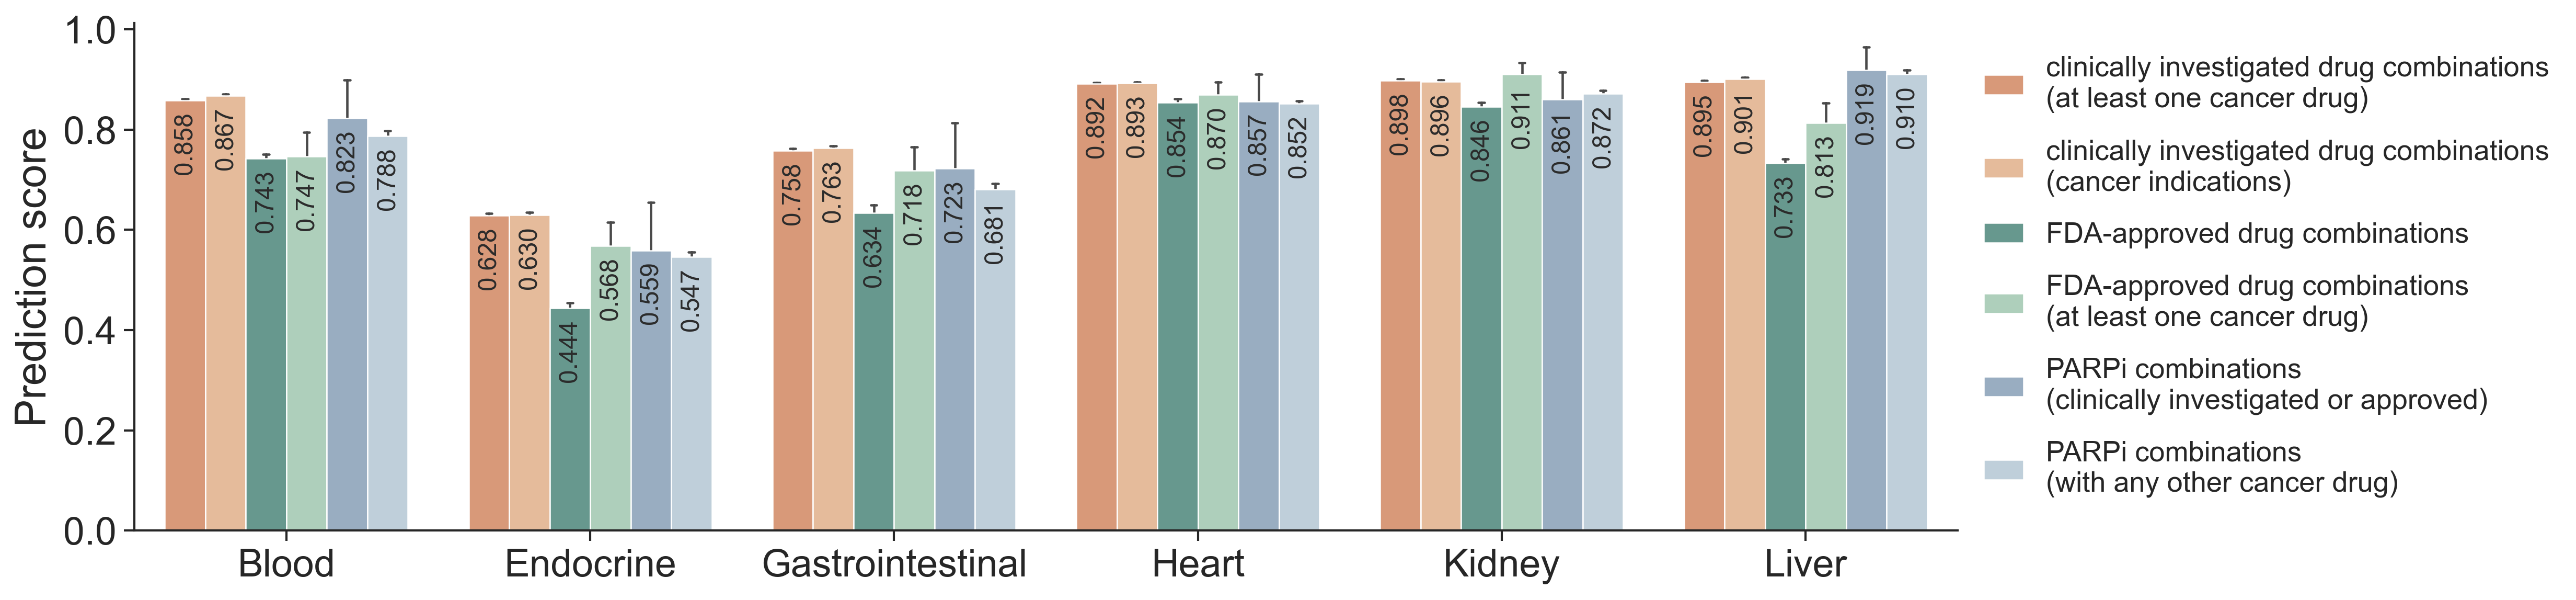

In [37]:
plot_data_all = (pd.melt(
    plot_data_highest_5_mean,
    id_vars=["drug_pair", "group"],
    value_vars=["liver", "gastrointestinal", "kidney", "blood", "heart", "endocrine"],
    var_name="organ",
).explode(column="value").reset_index(drop=True))

plot_data_all = plot_data_all[
    ~(
        (plot_data_all["drug_pair"].isin([k for k, v in parpi_drug_pairs_phase.items() if v == "phase 1"])) &
        (plot_data_all["group"] == "PARPi combinations (clinically investigated or approved)")
    )
]
# Display-cased organ names (Blood, Endocrine, ...) on the x-axis
plot_data_all["organ"] = plot_data_all["organ"].str.capitalize()

from matplotlib import font_manager as fm
arial_path = "../arial.ttf"
try:
    fm.fontManager.addfont(arial_path)
except OSError:
    pass
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.figure(figsize=(15, 4.2), dpi=300)
sns.set(style="ticks", context="paper", font_scale=2)

# Paired palette: clinically-investigated (orange family), FDA-approved (green family),
# PARPi (blue family). Darker shade = the broader "at least one cancer drug" variant.
custom_palette = [
    '#E89469',  # clinically investigated drug combinations (at least one cancer drug)
    '#F2B98E',  # clinically investigated drug combinations (cancer indications)
    '#5FA093',  # FDA-approved drug combinations
    '#A8D5BA',  # FDA-approved drug combinations (at least one cancer drug)
    '#92ADC8',  # PARPi combinations (clinically investigated or approved)
    '#BBD0DE',  # PARPi combinations (with any other cancer drug)
]
hue_order = [
    "clinically investigated drug combinations (at least one cancer drug)",
    "clinically investigated drug combinations (cancer indications)",
    "FDA-approved drug combinations",
    "FDA-approved drug combinations (at least one cancer drug)",
    "PARPi combinations (clinically investigated or approved)",
    "PARPi combinations (with any other cancer drug)",
]
organ_order = ["Blood", "Endocrine", "Gastrointestinal", "Heart", "Kidney", "Liver"]

ax = sns.barplot(
    data=plot_data_all.round(3),
    x="organ", y="value", hue="group",
    order=organ_order,
    hue_order=hue_order,
    palette=custom_palette,
    alpha=1.0,                    # opaque faces, so they fully occlude the error bars behind them
    edgecolor="white", linewidth=0.6,
    capsize=0.12,                 # the dashes at the whisker ends
    err_kws=dict(linewidth=1.1, color="#4a4a4a"),
)

# seaborn 0.13 draws the bars at zorder=1 and the error-bar Line2Ds at zorder=2, i.e. the
# error bars sit ON TOP of the bars. Flip it, so each error bar's lower half is hidden
# behind the bar face and only the upper whisker + its cap shows above the bar.
for line in ax.lines:
    line.set_zorder(1)
for patch in ax.patches:
    patch.set_zorder(2)

# Value labels on the bar faces (rotated, just inside the top edge), drawn above both.
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge',
                 rotation=90, padding=-34, fontsize=11.5, color="#2b2b2b", zorder=3)

sns.despine()

# Side legend with each label wrapped onto two lines at the qualifier "( ..."
handles, labels = ax.get_legend_handles_labels()
labels_wrapped = [l.replace(' (', '\n(', 1) for l in labels]
ax.legend(handles, labels_wrapped,
          bbox_to_anchor=(1.005, 0.5), loc='center left',
          frameon=False, fontsize=13, handlelength=1.4,
          labelspacing=0.9, borderaxespad=0.2)

plt.ylim(0.)
plt.ylabel("Prediction score")
plt.xlabel("")

plt.savefig("fig4_approved_clinical_trial_cancer_parpi_drug_combos_safety_comparison.svg", bbox_inches="tight", dpi=300)
plt.show()

## Organ-stratified safety for PARPi combinations

Aggregate all pairs for each PARPi, across organ

In [38]:
test_exploded, _ = add_organs_column(
    test_long, None, 
    organ_class_mapping, organs_of_interest, organ_counts, 
    sample_name_col_name="(parpi; pan cancer drug)", num_least_organ=5
)

In [39]:
test_exploded = test_exploded.drop(columns=["cancer drug id"]).groupby(by=["parpi", "cancer drug", "organ"]).agg(list)
test_exploded["organ_highest_5_mean"] = test_exploded["value"].apply(lambda lst: np.mean(np.partition(lst, len(lst)-5)[-5:]))
test_exploded["organ_highest_3_mean"] = test_exploded["value"].apply(lambda lst: np.mean(np.partition(lst, len(lst)-3)[-3:]))
test_exploded = test_exploded.reset_index()
test_exploded[["highest_5_ddi_class", "highest_5_values"]] = pd.DataFrame(test_exploded[["ddi_class", "value"]].apply(
    lambda row: [np.array(row[0])[np.argpartition(row[1], len(row[1])-5)[-5:]], np.partition(row[1], len(row[1])-5)[-5:]], axis=1
).tolist())
test_exploded[["highest_3_ddi_class", "highest_3_values"]] = pd.DataFrame(test_exploded[["ddi_class", "value"]].apply(
    lambda row: [np.array(row[0])[np.argpartition(row[1], len(row[1])-3)[-3:]], np.partition(row[1], len(row[1])-3)[-3:]], axis=1
).tolist())
test_exploded

,parpi,cancer drug,organ,ddi_class,value,organ_highest_5_mean,organ_highest_3_mean,highest_5_ddi_class,highest_5_values,highest_3_ddi_class,highest_3_values
0,olaparib,abemaciclib,blood,"[anticoagulant, decrease, anticoagulant, incre...","[0.6931248903274536, 0.593321681022644, 0.6300...",0.857686,0.916856,"[myelosuppression, increase, hemorrhage, incre...","[0.7642109394073486, 0.7736509442329407, 0.862...","[bleeding, gastrointestinal bleeding, increase...","[0.8623635172843933, 0.9999922513961792, 0.888..."
1,olaparib,abemaciclib,endocrine,"[Change in thyroid function, increase, hypergl...","[0.6472998857498169, 0.602527916431427, 0.4594...",0.545817,0.574605,"[hypoglycemia, increase, hyperglycemia, increa...","[0.47398680448532104, 0.602527916431427, 0.459...","[hypoglycemia, increase, Change in thyroid fun...","[0.47398680448532104, 0.6472998857498169, 0.60..."
2,olaparib,abemaciclib,gastrointestinal,"[bleeding, gastrointestinal bleeding, increase...","[0.8623635172843933, 0.39101165533065796, 0.88...",0.777313,0.913164,"[urinary retention, reduced gastrointestinal m...","[0.5407595634460449, 0.6063113212585449, 0.992...","[bleeding, gastrointestinal bleeding, increase...","[0.8623635172843933, 0.8846448063850403, 0.992..."
3,olaparib,abemaciclib,heart,"[QTc prolongation, decrease, QTc prolongation,...","[0.4269298017024994, 0.24116678535938263, 0.52...",0.896653,0.930282,"[orthostatic hypotension, syncope, increase, h...","[0.8412537574768066, 0.8511660099029541, 0.997...","[vasospastic reactions, increase, hypercalcemi...","[0.8697309494018555, 0.9237474799156189, 0.997..."
4,olaparib,abemaciclib,kidney,"[antihypertension, decrease, antihypertension,...","[0.5254014134407043, 0.16923998296260834, 0.66...",0.915797,0.971571,"[ototoxicity, nephrotoxicity, increase, excret...","[0.8131041526794434, 0.9922599792480469, 0.851...","[hypercalcemia, increase, excretion, decrease,...","[0.9237474799156189, 0.9922599792480469, 0.998..."
...,...,...,...,...,...,...,...,...,...,...,...
6022,talazoparib,zoledronic acid,gastrointestinal,"[bleeding, gastrointestinal bleeding, increase...","[0.22719281911849976, 0.15843424201011658, 0.3...",0.316465,0.375849,"[bleeding, gastrointestinal bleeding, increase...","[0.22719281911849976, 0.22758641839027405, 0.3...","[gastrointestinal bleeding, increase, ulcerati...","[0.3134324550628662, 0.3210504353046417, 0.493..."
6023,talazoparib,zoledronic acid,heart,"[QTc prolongation, decrease, QTc prolongation,...","[0.09515265375375748, 0.7683120369911194, 0.44...",0.665089,0.709563,"[hypotension, increase, QTc prolongation, tors...","[0.5524042248725891, 0.6443519592285156, 0.670...","[orthostatic hypotension, dizziness, increase,...","[0.670571506023407, 0.689805805683136, 0.76831..."
6024,talazoparib,zoledronic acid,kidney,"[antihypertension, decrease, antihypertension,...","[0.38089215755462646, 0.14727425575256348, 0.1...",0.629792,0.736325,"[nephrotoxicity, increase, fluid retention, va...","[0.46627527475357056, 0.47370925545692444, 0.5...","[hypotension, increase, excretion, decrease, n...","[0.5524042248725891, 0.6787683367729187, 0.977..."
6025,talazoparib,zoledronic acid,liver,"[excretion rate, decrease | serum level, incre...","[0.37753191590309143, 0.21507035195827484, 0.6...",0.478872,0.600237,"[excretion, increase, liver damage, increase, ...","[0.21611598134040833, 0.6936696171760559, 0.42...","[liver enzyme elevations, increase, excretion,...","[0.42827337980270386, 0.6787683367729187, 0.69..."


In [40]:
valid_drugs_list = []
for drug_id in all_other_drugs_list:
    drug_ind = drug_id_to_ind[drug_id]
    temp = organs_csv.iloc[db_polypharmacy[(db_polypharmacy['drug_index_1'] == drug_ind)]["label_indexed"]]
    temp["count"] = 1
    if set(["blood", "liver", "kidney"]) - set(temp.groupby(by=["ddi_class", "organ"]).agg(sum).reset_index().query("count >= 5")["organ"].str.split(", ").explode().tolist()) == set():
        valid_drugs_list.append(drug_id)

In [41]:
np.random.seed(42)
ctrl_drug_ids = np.random.choice(valid_drugs_list, size=50, replace=False)
ctrl_df = pd.DataFrame({
    "node_id": ctrl_drug_ids,
    "node_name": [drug_id_to_name[drug_id] for drug_id in ctrl_drug_ids],
})
pan_cancer_ctrl_df, pan_cancer_ctrl_df_filtered = get_parpi_cancer_drug_ddi_scores(ctrl_df, "pan", pan_cancer_drugs)

ctrl_long = pd.melt(
    pan_cancer_ctrl_df_filtered.reset_index(), 
    id_vars=pan_cancer_ctrl_df_filtered.index.name,
    value_vars=pan_cancer_ctrl_df_filtered.columns, 
    var_name="ddi_class"
)
ctrl_long[["parpi", "cancer drug"]] = ctrl_long["(parpi; pan cancer drug)"].str.split("; ", expand=True)
ctrl_long["cancer drug id"] = ctrl_long["cancer drug"].apply(lambda x: drug_name_to_id[x])
ctrl_long = ctrl_long.drop(columns=["(parpi; pan cancer drug)"])[["parpi", "cancer drug", "cancer drug id", "ddi_class", "value"]]

ctrl_exploded, _ = add_organs_column(
    ctrl_long, None, 
    organ_class_mapping, organs_of_interest, organ_counts, 
    sample_name_col_name="(parpi; pan cancer drug)", num_least_organ=5
)

ctrl_exploded = ctrl_exploded.drop(columns=["cancer drug id"]).groupby(by=["parpi", "cancer drug", "organ"]).agg(list)
ctrl_exploded["organ_highest_5_mean"] = ctrl_exploded["value"].apply(lambda lst: np.mean(np.partition(lst, len(lst)-5)[-5:]))
ctrl_exploded["organ_highest_3_mean"] = ctrl_exploded["value"].apply(lambda lst: np.mean(np.partition(lst, len(lst)-3)[-3:]))
ctrl_exploded["organ_highest_2_mean"] = ctrl_exploded["value"].apply(lambda lst: np.mean(np.partition(lst, len(lst)-2)[-2:]))
ctrl_exploded = ctrl_exploded.reset_index()
ctrl_exploded[["highest_5_ddi_class", "highest_5_values"]] = pd.DataFrame(ctrl_exploded[["ddi_class", "value"]].apply(
    lambda row: [np.array(row[0])[np.argpartition(row[1], len(row[1])-5)[-5:]], np.partition(row[1], len(row[1])-5)[-5:]], axis=1
).tolist(), index=ctrl_exploded.index)
ctrl_exploded[["highest_3_ddi_class", "highest_3_values"]] = pd.DataFrame(ctrl_exploded[["ddi_class", "value"]].apply(
    lambda row: [np.array(row[0])[np.argpartition(row[1], len(row[1])-3)[-3:]], np.partition(row[1], len(row[1])-3)[-3:]], axis=1
).tolist(), index=ctrl_exploded.index)
ctrl_exploded

,parpi,cancer drug,organ,ddi_class,value,organ_highest_5_mean,organ_highest_3_mean,organ_highest_2_mean,highest_5_ddi_class,highest_5_values,highest_3_ddi_class,highest_3_values
0,amphotericin b,abemaciclib,blood,"[anticoagulant, decrease, anticoagulant, incre...","[0.7359289526939392, 0.5216501951217651, 0.741...",0.946598,0.973763,0.981144,"[neutropenia, increase, jaw osteonecrosis, ant...","[0.8719937801361084, 0.9397094249725342, 0.959...","[neutropenia, thrombocytopenia, increase, myel...","[0.9590008854866028, 0.9723440408706665, 0.989..."
1,amphotericin b,abemaciclib,endocrine,"[Change in thyroid function, increase, hypergl...","[0.7866073846817017, 0.6325721740722656, 0.618...",0.635621,0.679347,0.709590,"[hypoglycemia, increase, hyperglycemia, increa...","[0.5044440031051636, 0.6325721740722656, 0.618...","[hypertension, hyponatremia, water intoxicatio...","[0.618861973285675, 0.6325721740722656, 0.7866..."
2,amphotericin b,abemaciclib,gastrointestinal,"[bleeding, gastrointestinal bleeding, increase...","[0.6479136347770691, 0.6201907396316528, 0.604...",0.848992,0.890622,0.930981,"[urinary retention, reduced gastrointestinal m...","[0.7732259035110474, 0.7998647689819336, 0.809...","[gastrointestinal ulceration, increase, ulcera...","[0.8099050521850586, 0.973376989364624, 0.8885..."
3,amphotericin b,abemaciclib,heart,"[QTc prolongation, decrease, QTc prolongation,...","[0.9050755500793457, 0.9615474343299866, 0.831...",0.953409,0.960260,0.966047,"[antihypertension, increase, vasodilatory, inc...","[0.9424041509628296, 0.9438619613647461, 0.961...","[atrioventricular blocking (AV block), increas...","[0.9486860632896423, 0.9615474343299866, 0.970..."
4,amphotericin b,abemaciclib,kidney,"[antihypertension, decrease, antihypertension,...","[0.6717873215675354, 0.9424041509628296, 0.649...",0.945481,0.969950,0.983722,"[ototoxicity, nephrotoxicity, increase, nephro...","[0.9013363122940063, 0.9678205251693726, 0.942...","[antihypertension, increase, excretion, decrea...","[0.9424041509628296, 0.9996240735054016, 0.967..."
...,...,...,...,...,...,...,...,...,...,...,...,...
100445,vancomycin,zoledronic acid,gastrointestinal,"[bleeding, gastrointestinal bleeding, increase...","[0.2451237291097641, 0.04028988257050514, 0.35...",0.244224,0.284955,0.304871,"[reduced gastrointestinal motility, increase, ...","[0.16361787915229797, 0.20263798534870148, 0.2...","[bleeding, gastrointestinal bleeding, increase...","[0.2451237291097641, 0.25574758648872375, 0.35..."
100446,vancomycin,zoledronic acid,heart,"[QTc prolongation, decrease, QTc prolongation,...","[0.17479389905929565, 0.43519923090934753, 0.1...",0.690057,0.844424,0.979869,"[QTc prolongation, hypotension, increase, vaso...","[0.43519923090934753, 0.481810599565506, 0.573...","[fluid retention, vasopressor, increase, hypoc...","[0.573534369468689, 0.9895173907279968, 0.9702..."
100447,vancomycin,zoledronic acid,kidney,"[antihypertension, decrease, antihypertension,...","[0.13206619024276733, 0.09193094074726105, 0.0...",0.841677,0.976836,0.994746,"[fluid retention, vasopressor, increase, nephr...","[0.573534369468689, 0.9999744296073914, 0.7043...","[nephrotoxicity, increase, hypocalcemia, incre...","[0.9410149455070496, 0.9895173907279968, 0.999..."
100448,vancomycin,zoledronic acid,liver,"[excretion rate, decrease | serum level, incre...","[0.1490016132593155, 0.02965320274233818, 0.51...",0.518079,0.762398,0.885192,"[excretion rate, decrease | serum level, incre...","[0.1490016132593155, 0.15419723093509674, 0.92...","[excretion, decrease, metabolism, decrease, li...","[0.5168119072914124, 0.8462592363357544, 0.924..."


13:15:57   No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


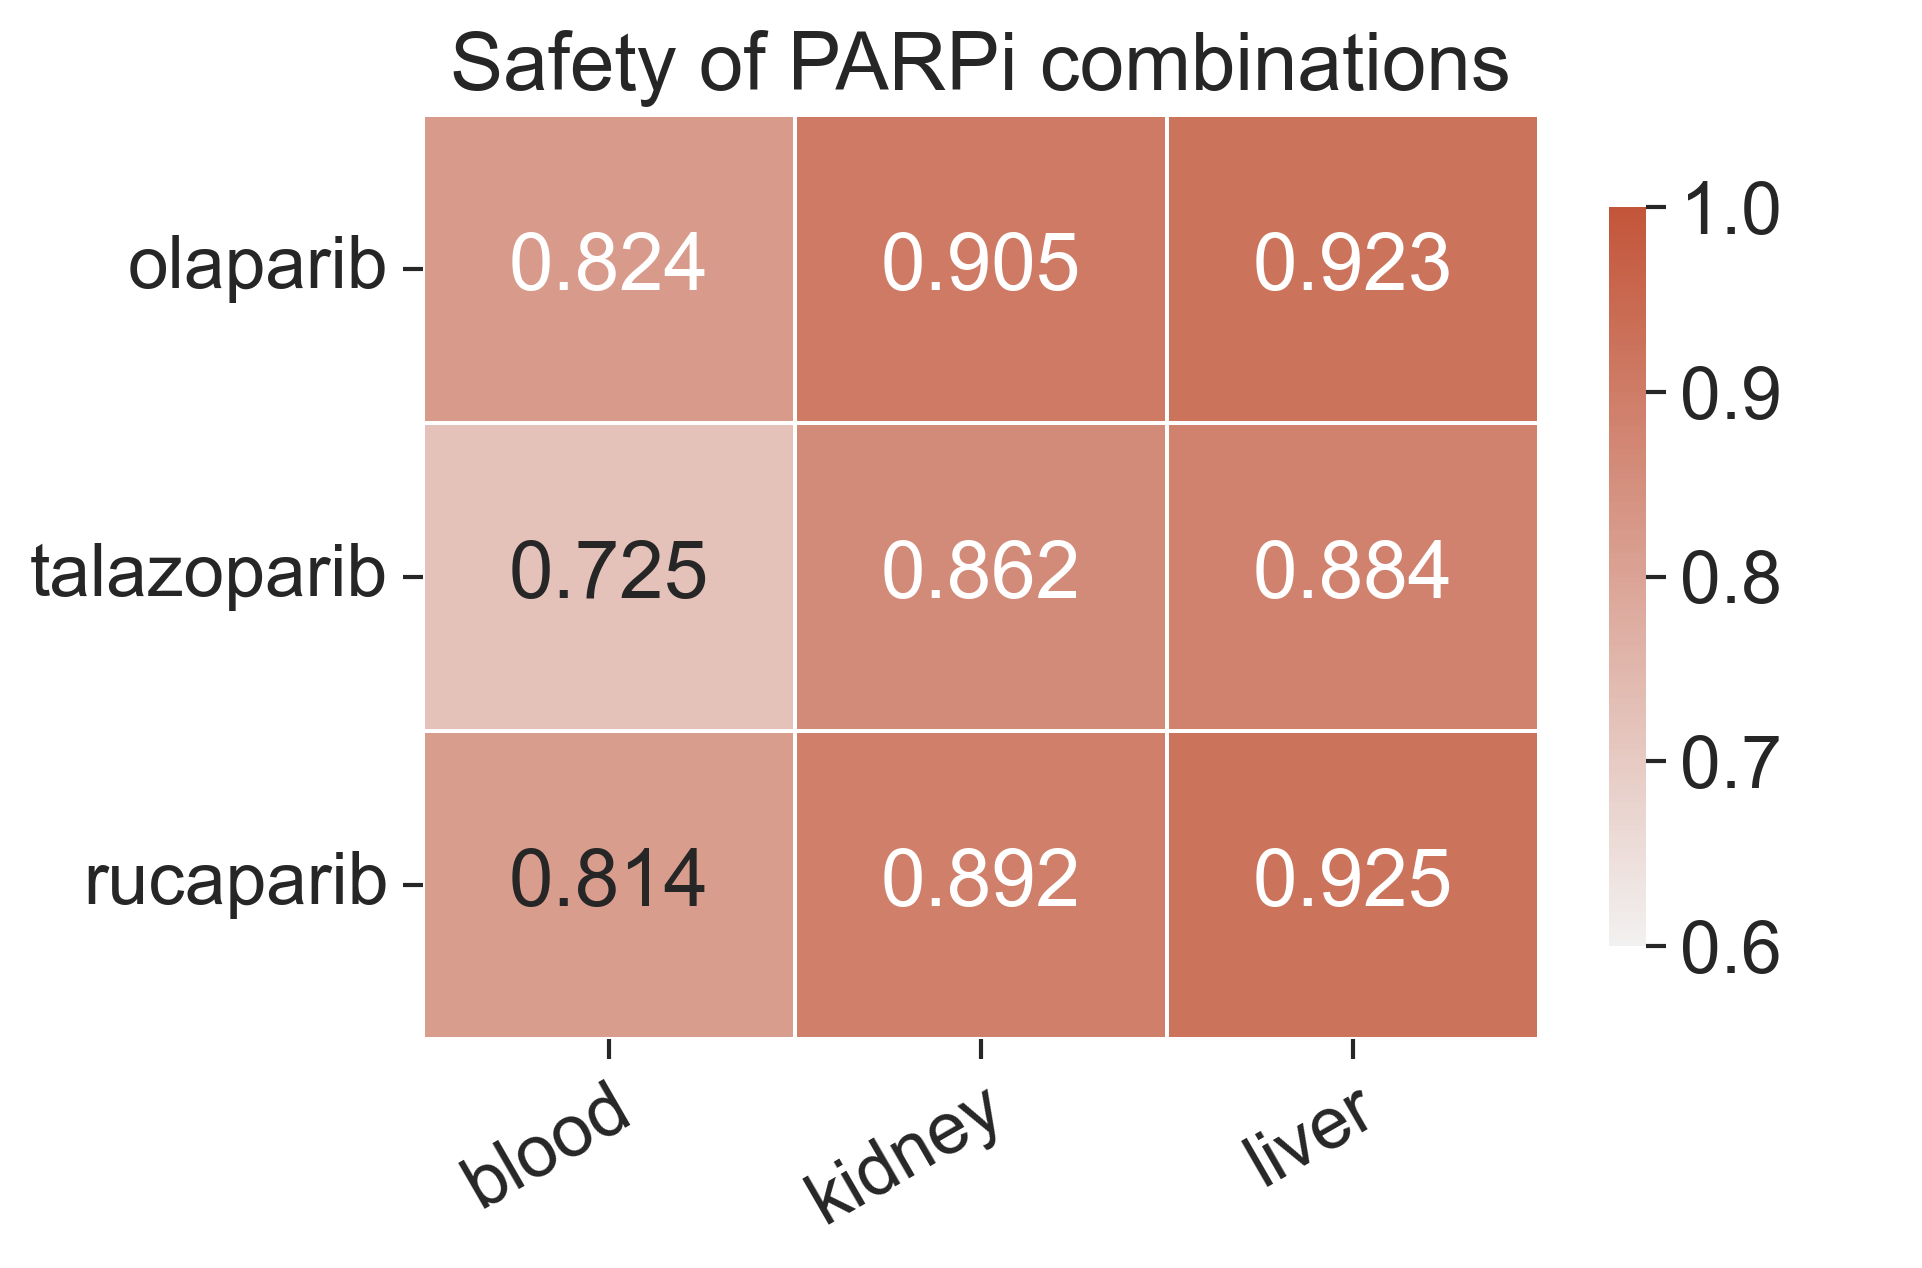

In [42]:
temp = test_exploded[["parpi", "organ", "organ_highest_5_mean"]].groupby(by=["parpi", "organ"]).agg(np.mean).reset_index()
temp = pd.pivot_table(temp, values="organ_highest_5_mean", index="parpi", columns="organ").loc[
    [
        "olaparib", 
        "talazoparib", 
        "rucaparib", 
    ],
    [
        "blood", 
        "kidney", 
        "liver",
    ]
]

plt.figure(figsize=(6, 4), dpi=300)
sns.set(context="paper", style="ticks", font_scale=2)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    temp, annot=True, 
    fmt=".3f",
    cmap=cmap, 
    linewidths=.5,
    cbar_kws={"shrink": .8}, 
    center=.6, 
    vmax=1.0, vmin=0.6,
)

plt.title('Safety of PARPi combinations')
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=30, rotation_mode="anchor", ha="right")
plt.legend(bbox_to_anchor=(1.35, 1.0), loc='upper right', frameon=False)

plt.savefig("fig4_parpi_combos_safety_heatmap.svg", bbox_inches="tight", dpi=300)
plt.show()

## Visualizing safety for clinically-investigating PARPi combinations

Plot the clinically investigating combinations with their ranks among all pairs

In [38]:
papi_cancer_drug_for_stripplot = []
ddi_scores_for_stripplot = []
ddi_classes_for_stripplot = []
ddi_organs_for_stripplot = []
assert max(sum(specific_organs_mapping.values(), start=[])) == 150

for parpi_name, cancer_drug_list in studied_parpi_combos.items():
    if parpi_name == "olaparib": cancer_drug_list += ["paclitaxel"]  # positive control
    for cancer_drug_name in cancer_drug_list:
        if cancer_drug_name in drug_metadata["node_name"].dropna().str.lower().values:
            print(parpi_name, cancer_drug_name)
            parpi_index = drug_name_to_ind[parpi_name]
            cancer_drug_index = drug_name_to_ind[cancer_drug_name]
            ddi_filtered = normalized_rank_drugbank[:, parpi_index, cancer_drug_index][valid_ddi_class_indices]

            # specific_organs_mapping
            for organ, organ_ddi_index_lst in specific_organs_mapping.items():
                ddi_scores_for_stripplot.extend(ddi_filtered[organ_ddi_index_lst])
                ddi_classes_for_stripplot.extend(ddi_classes[valid_ddi_class_indices][organ_ddi_index_lst])
                ddi_organs_for_stripplot.extend([organ] * len(organ_ddi_index_lst))
                papi_cancer_drug_for_stripplot.extend([f"{parpi_name}; {cancer_drug_name}"] * len(organ_ddi_index_lst))

olaparib temozolomide
olaparib cediranib
olaparib alpelisib
olaparib capivasertib
olaparib selumetinib
olaparib ceralasertib
olaparib prexasertib
olaparib mk-1775
olaparib abiraterone
olaparib paclitaxel
veliparib paclitaxel
veliparib carboplatin
veliparib cisplatin
veliparib gemcitabine
veliparib temozolomide
veliparib irinotecan
veliparib fluorouracil
veliparib lapatinib
rucaparib temozolomide
talazoparib enzalutamide
niraparib abiraterone


In [39]:
studied_pairs_df_filtered = pd.DataFrame.from_dict({
    "(parpi; pan cancer drug)": papi_cancer_drug_for_stripplot,
    "ddi_class": ddi_classes_for_stripplot,
    "value": ddi_scores_for_stripplot,
    "organ": ddi_organs_for_stripplot,
})
studied_pairs_df_filtered

,(parpi; pan cancer drug),ddi_class,value,organ
0,olaparib; temozolomide,"CNS depression, hypotonia, increase",0.816265,others/general
1,olaparib; temozolomide,"CNS depression, increase",0.390814,others/general
2,olaparib; temozolomide,"absorption, decrease",0.429326,others/general
3,olaparib; temozolomide,"absorption, decrease | serum level, decrease |...",0.709453,others/general
4,olaparib; temozolomide,"absorption, increase | serum level, increase |...",0.850047,others/general
...,...,...,...,...
3754,niraparib; abiraterone,"excretion, increase",0.524087,liver
3755,niraparib; abiraterone,"liver damage, increase",0.325989,liver
3756,niraparib; abiraterone,"liver enzyme elevations, increase",0.393204,liver
3757,niraparib; abiraterone,"metabolism, decrease",0.020877,liver


In [40]:
studied_pairs_df_filtered["drug_pair_with_phase"] = (
    studied_pairs_df_filtered["(parpi; pan cancer drug)"] + "\n(" + \
    studied_pairs_df_filtered["(parpi; pan cancer drug)"].apply(lambda x: parpi_drug_pairs_phase[x]) + \
    ")"
)

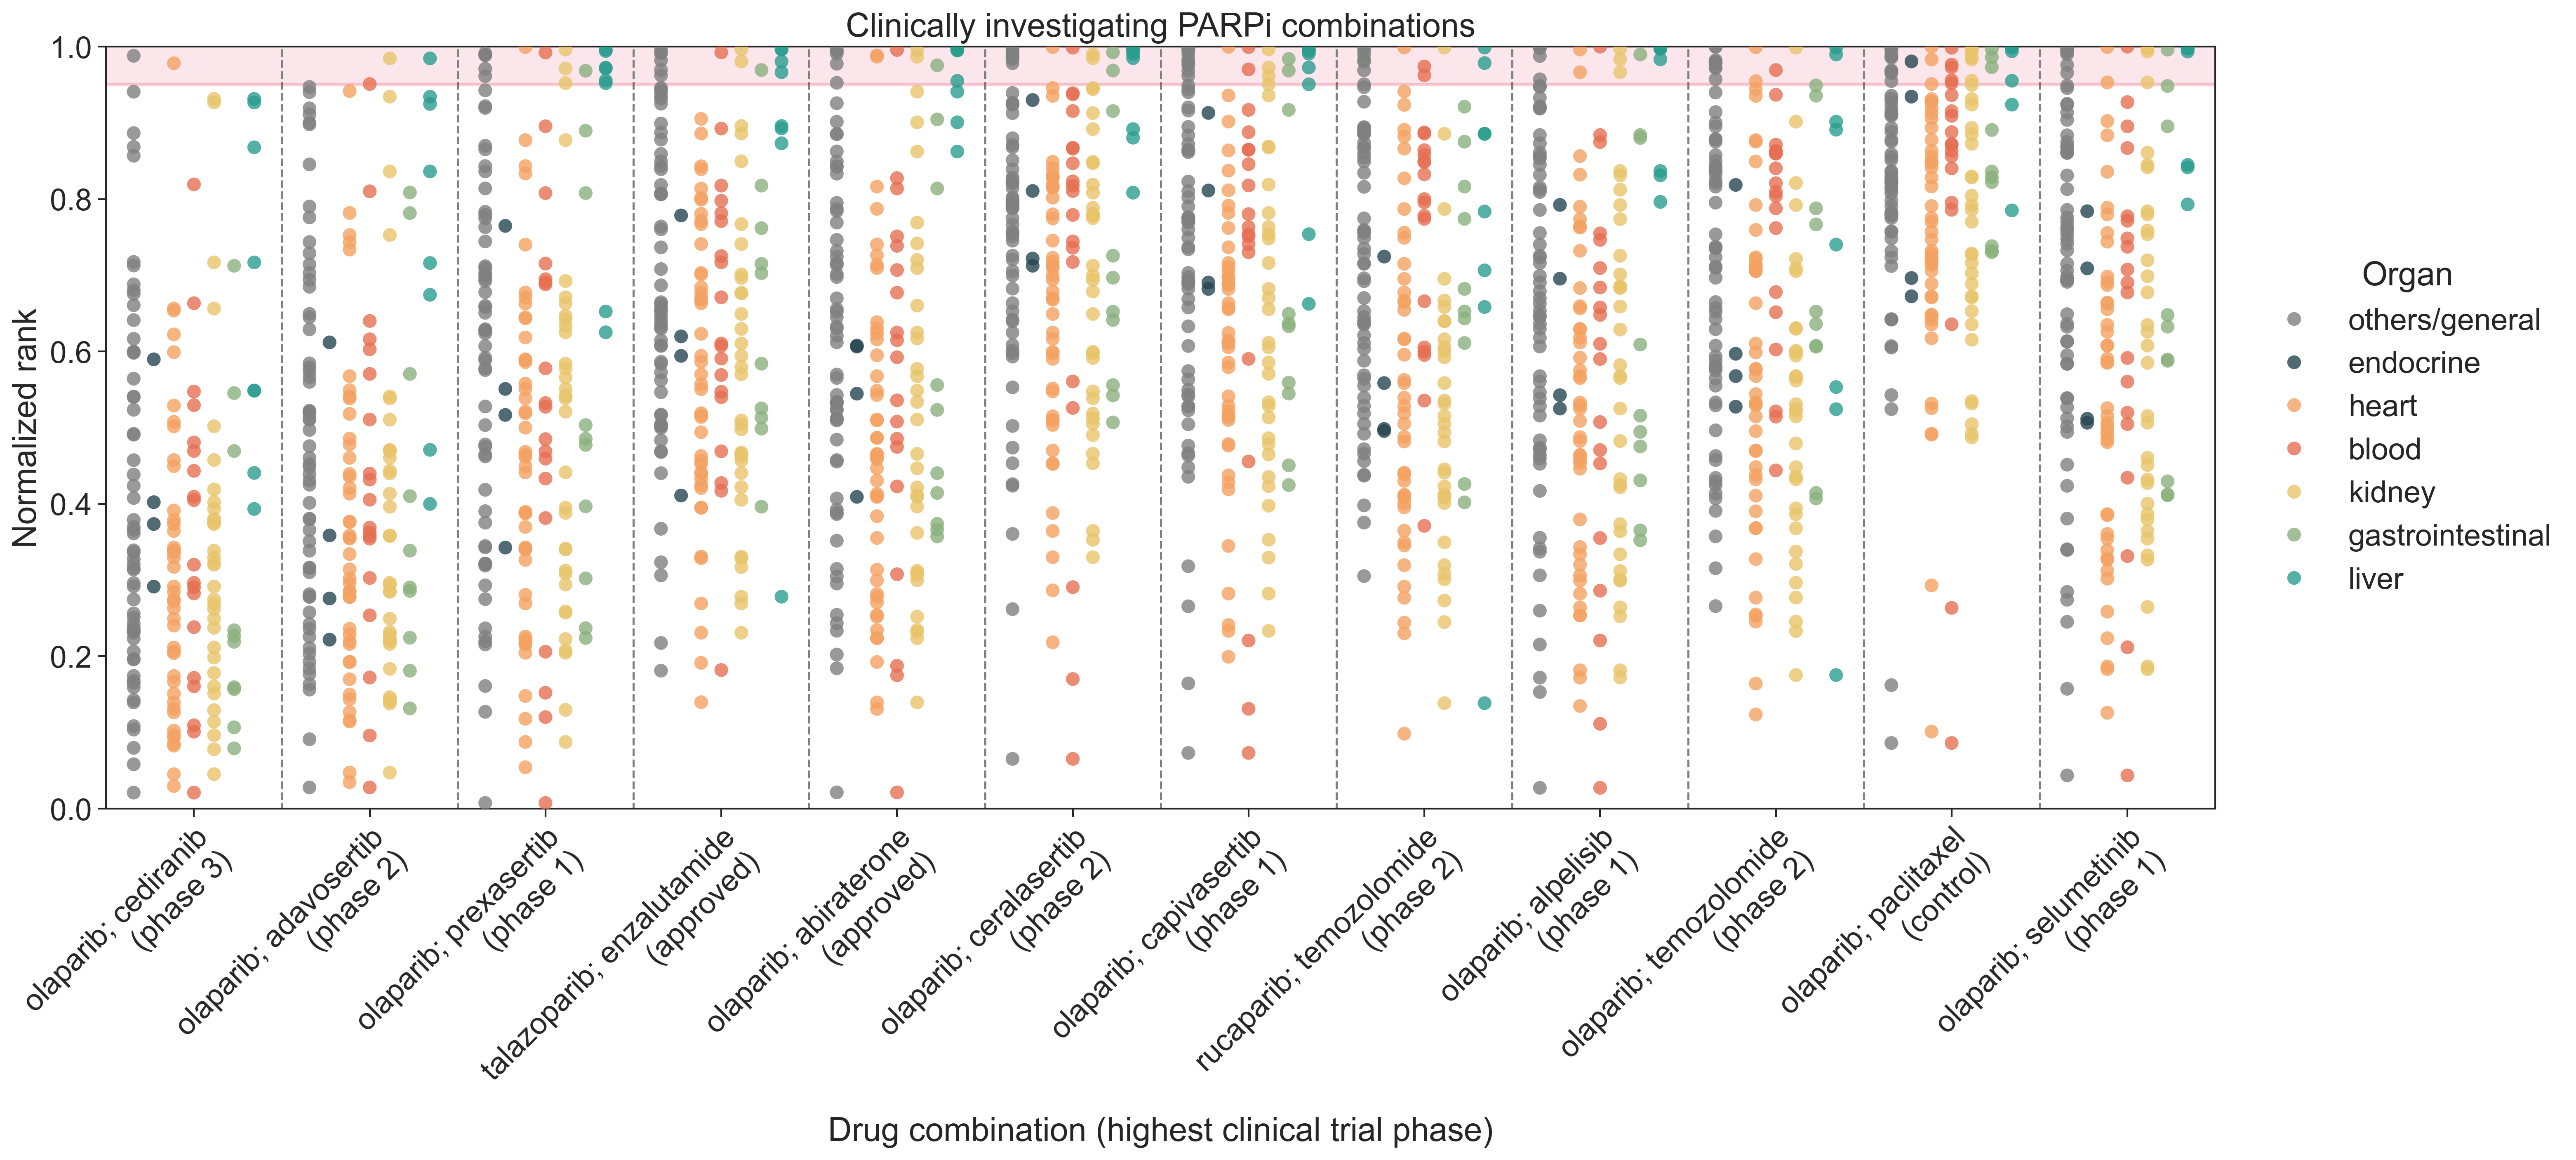

In [47]:
plot_title = "Clinically investigating PARPi combinations"
sample_name_col_name = "drug_pair_with_phase"
print_ddi_class_or_organ_num = "organ_num"
custom_palette = {
    "others/general": "grey", 
    "blood": "#e76f51",  # lightpink
    "heart": "#f4a261",  # marron
    "kidney": "#e9c46a",  # darkmagenta
    "gastrointestinal": "#8ab17d",  # mediumseagreen
    "liver": "#2a9d8f",  # cornflowerblue, steelblue
    "endocrine": "#264653",
}

studied_pairs_df_filtered["(parpi; pan cancer drug)"] = studied_pairs_df_filtered["(parpi; pan cancer drug)"].str.replace("mk-1775", "adavosertib")
studied_pairs_df_filtered["drug_pair_with_phase"] = studied_pairs_df_filtered["drug_pair_with_phase"].str.replace("mk-1775", "adavosertib")
plot_data = studied_pairs_df_filtered.copy()
plot_data = plot_data[~plot_data["(parpi; pan cancer drug)"].str.contains("veliparib")]
plot_data = plot_data[~plot_data["(parpi; pan cancer drug)"].str.contains("niraparib")]

# Initialize the figure
plt.figure(figsize=(22, 8), dpi=300)
plt.rcParams["font.family"] = "Arial"
sns.set(style="ticks", context="paper", font_scale=2)

# Show each observation with a scatterplot
order = plot_data.groupby(sample_name_col_name).agg(list)["value"].apply(
    lambda x: np.mean(np.partition(x, len(x)-5)[-5:])
).sort_values().index.values
sns.stripplot(
    data=plot_data, y="value", x=sample_name_col_name, hue="organ", 
    palette=custom_palette, dodge=1.0, jitter=False, alpha=.8, order=order, s=8
)

# Put dashed horizontal lines to separate the drug combinations
x = 0.5
while x < 11.5:
    plt.axvline(x=x, ymin=-0.5, ymax=3.5, ls="--", color="grey")
    x += 1

threshold_to_count_ddi = 0.95
plt.ylim([0, 1])
plt.xlim([-0.5, 11.5])
plt.axhline(y=threshold_to_count_ddi, c="crimson", lw=2, alpha=0.2)
plt.axhspan(threshold_to_count_ddi, 1.0, color="crimson", alpha=0.1, lw=0)
plt.ylabel("Normalized rank")
plt.xlabel("Drug combination (highest clinical trial phase)")
plt.title(plot_title)
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.legend(bbox_to_anchor=(1.01, 0.5), loc='center left', frameon=False, title="Organ")

plt.savefig("./fig4_clinically_investigating_parpi_cancer_drug_pairs_stripplot_bottleneck.svg", format="svg", dpi=300)
plt.show()